# Representation of signals & inverse problems - G1-G2

## Lab 2: Wavelet transform and image processing

## Guidelines (read carefully before starting)

**Objective**: this lab explores some aspects of orthogonal wavelet transforms in 2D for image processing, with applications to denoising and filtering. All the numerical illustrations covered in this session rely on the Python module `Pywavelets`.

Each wavelet is determined by its low-pass filter or scaling function (in french *fonction d'échelle* ). The longer this filter (*i.e.*, the more coefficients it contains), the larger the number of null moments. For instance, Daubechies wavelets are composed of $p = 2k$ coefficients, for $k$ null moments.

A larger number of null moments allows regular signals/images to be better compressed. However, an extended support of the wavelet can be problematic to represent highly irregular regions of the signal, such as discontinuities.

The choice of a wavelet is a matter of compromise, depending on the type of structures expected to be observed in the image of interest.

**Guidelines**: after retrieving the resources for the lab on moodle:

- place the .zip archive in a local folder (Computer -> Documents/Python/);
- unzip the archive .zip;
- rename the folder with the convention lab2_Name1_Name2
- duplicate the notebook file and rename it lab2_Name1_Name2.ipynb;
- [**optional, possibly needed if working from Centrale's machines**]
    - create a `rsp` conda environment from the provided `requirement.txt` file
    ```bash
    conda create --name=rsp --file=requirement.txt
    conda activate rsp
    conda deactivate rsp # to deactivate the conda environment
    # do not forget to deactivate the environment if needed
    # you can remove the environment once you are done
    conda env remove --name=rsp
    ```
    - launch jupyter notebook (the python environment will be the one from the conda environment `rsp`)
- at the end of the session, do not forget to transfer your work to your own network space if you are working on a machine from the school (do not leave your work on the C: drive).
- if needed, an excellent tutorial on the use of Python for scientific computing can be found in the Scipy lecture notes.

**Assessment** → global grade from F to A (A+)

This lab session will be evaluated, based on your answer to the exercises reported in a Jupyter notebook (e.g., this one) and any additional `.py` file produced. Any code produced should be commented whenever appropriate, custom functions and objects documented. Figures produced should be clearly annotated (axis, title, legend whenever appropriate).

1. Numerical correctness
2. Implementation clarity (documentation, relevance of the comments)
3. Answers to the questions and overall presentation of the Jupyter notebook.

**PyWavelets** is an open source wavelet transform package for Python. It combines a simple high level interface with low level C and Cython performance.

It is very easy to use and get started with. If the package is not already installed (it should be if you use a conda environment created from the above instructions), open the Python interactive anaconda prompt and type:

- `conda install pywavelets`

Further details available at: https://pywavelets.readthedocs.io/en/latest/ref/index.html

## Configuration

> **About the resources of this folder**
>
> - `img/chessboard.png`: 512 x 512 chessboard with squares of 64 pixels, generated exactly.
> - `img/boat.png`: the "boat" test image of the USC-SIPI database. `img/lena.jpg`: the "Lena" test image. Both are 512 x 512 grey-level images.
> - `lib/module_TDS.py`, `lib/plotwavelet.py`: replacements of the modules provided on Moodle.
>
> The noise of the denoising part is generated with a fixed seed, so that the PSNR values quoted in the answers are reproducible.

In [1]:
# make sure the notebook reloads the module each time we modify it
%load_ext autoreload
%autoreload 2

# figures displayed below the cells
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import matplotlib.image as mpimg

from scipy.signal import *
from scipy.io.wavfile import *
from scipy.io import *
from numpy.fft import *
from matplotlib.colors import LogNorm  # for Log normalization

# Browser-based audio player: portable and independent of a system audio device
from IPython.display import Audio, display

from lib.module_TDS import *
from lib.plotwavelet import *

## Contents

1. 1D discrete wavelet transform
    - Exercise 1
2. 2D discrete wavelet transform
    - Exercise 2
3. Wavelet filtering
    - Exercise 3
4. Wavelet denoising
    - Exercise 4
    - Exercise 5 (optional)

## 1D discrete wavelet transform

The Discrete Wavelet Transform (DWT) of a signal can be computed with the `pywt.dwt` and `pywt.wavedec` functions (see the example below). The result is stored in a dictionary of arrays containing each octave separately, as well as the approximation level.

An example of application to a chirp signal is reported below, illustrating the multiresolution analysis of a wideband signal.

In [3]:
N = 2 ** 13
Fs = 1024  # 2**10
t = np.arange(0, N, 1) / Fs
x = chirp(t, f0=60, f1=2, t1=10, method="hyperbolic")

display(Audio(x, rate=Fs * 44))  # artificial change of Fs for listening

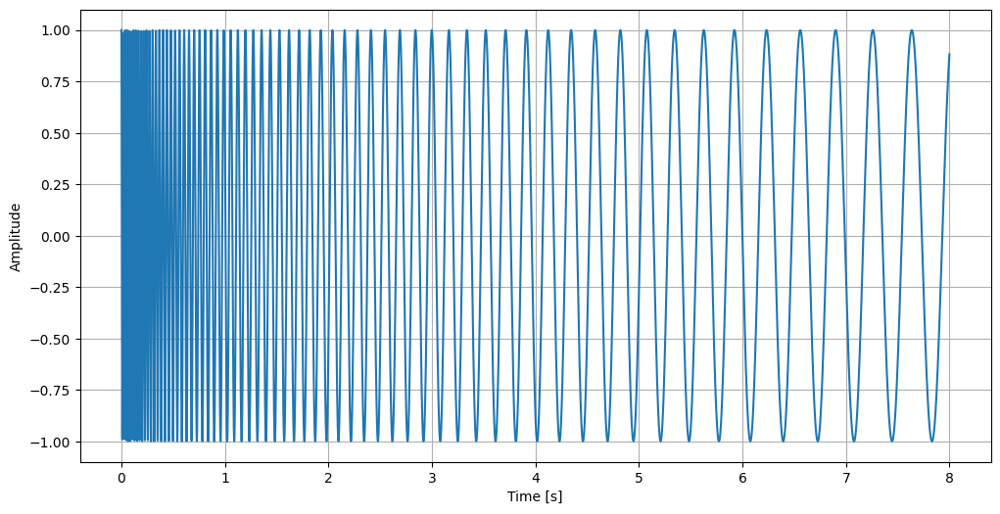

In [4]:
figure(figsize=(12, 6))
plot(t, x)
xlabel("Time [s]")
# xlim( 0, 1 )
ylabel(r"Amplitude")
grid()
show()

Different wavelets are available. Use the `pywt.wavelist()` command to display the list of the available built-in wavelets.

In [5]:
pywt.wavelist() # uncomment to run the command

['bior1.1',
 'bior1.3',
 'bior1.5',
 'bior2.2',
 'bior2.4',
 'bior2.6',
 'bior2.8',
 'bior3.1',
 'bior3.3',
 'bior3.5',
 'bior3.7',
 'bior3.9',
 'bior4.4',
 'bior5.5',
 'bior6.8',
 'cgau1',
 'cgau2',
 'cgau3',
 'cgau4',
 'cgau5',
 'cgau6',
 'cgau7',
 'cgau8',
 'cmor',
 'coif1',
 'coif2',
 'coif3',
 'coif4',
 'coif5',
 'coif6',
 'coif7',
 'coif8',
 'coif9',
 'coif10',
 'coif11',
 'coif12',
 'coif13',
 'coif14',
 'coif15',
 'coif16',
 'coif17',
 'db1',
 'db2',
 'db3',
 'db4',
 'db5',
 'db6',
 'db7',
 'db8',
 'db9',
 'db10',
 'db11',
 'db12',
 'db13',
 'db14',
 'db15',
 'db16',
 'db17',
 'db18',
 'db19',
 'db20',
 'db21',
 'db22',
 'db23',
 'db24',
 'db25',
 'db26',
 'db27',
 'db28',
 'db29',
 'db30',
 'db31',
 'db32',
 'db33',
 'db34',
 'db35',
 'db36',
 'db37',
 'db38',
 'dmey',
 'fbsp',
 'gaus1',
 'gaus2',
 'gaus3',
 'gaus4',
 'gaus5',
 'gaus6',
 'gaus7',
 'gaus8',
 'haar',
 'mexh',
 'morl',
 'rbio1.1',
 'rbio1.3',
 'rbio1.5',
 'rbio2.2',
 'rbio2.4',
 'rbio2.6',
 'rbio2.8',
 'rbio3.1',

#### Computing your first orthogonal wavelet transform

The function `pywt.dwt` computes the wavelet transform for a single decomposition level, returning the corresponding approximation coefficients and details.

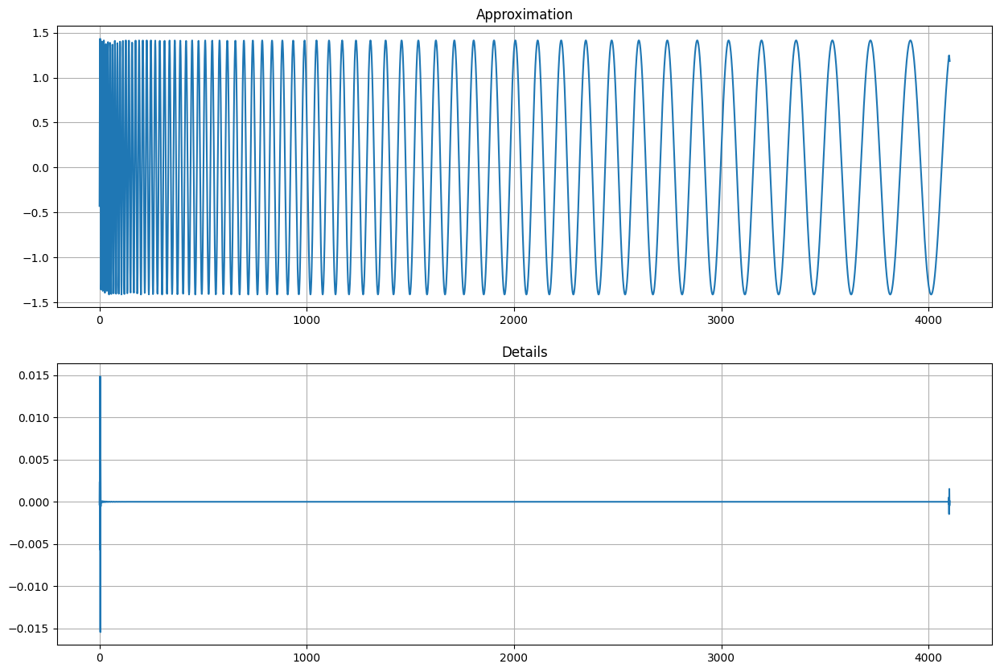

In [6]:
cA, cD = pywt.dwt(x, "sym8")

figure(figsize=(15, 10))
subplot(211)
plot(cA)
title("Approximation")
grid()
subplot(212)
plot(cD)
title("Details")
grid()
show()

The `pywt.wavedec` function computes a multi-level wavelet transform. It returns an ordered list of coefficients arrays, where `level` denotes the number of decomposition levels. Wavelet coefficients are stored in an object `coeff`. The first element `coeff[0]` is an array containing approximation coefficients. The following elements `coeff[i]` are arrays containing the details coefficients at the different scales.

In [7]:
coeff = pywt.wavedec(x, "sym8", level=7)

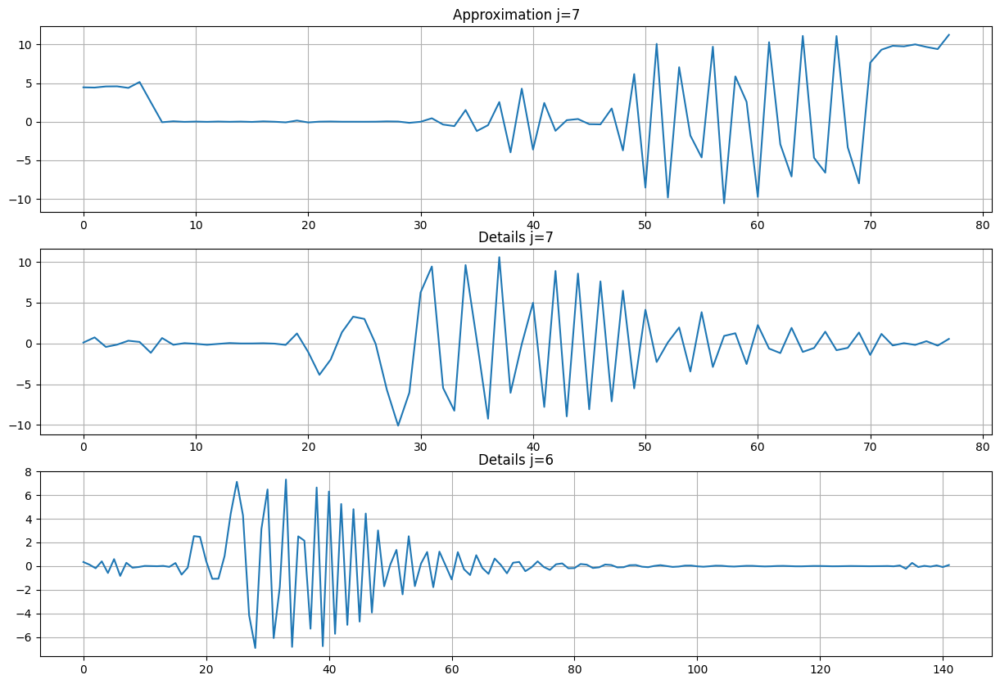

In [8]:
figure(figsize=(15, 10))
subplot(311)
plot(coeff[0])
title("Approximation j=7")
grid()
subplot(312)
plot(coeff[1])
title("Details j=7")
grid()
subplot(313)
plot(coeff[2])
title("Details j=6")
grid()
show()

### Exercise 1

1. Read the documentation of the functions `pywt.dwt`, `pywt.idwt` and `pywt.wavedec`. What are these functions used for? What is the difference between these functions?
2. The smallest scales can be filtered out by setting the associated wavelet coefficients to zero. Illustrate the effect of nulling some coefficients of the details (or the approximation) for a given set of octaves. *Indication: to do this, you need to compute the wavelet transform, set some coefficients to zero and then reconstruct the signal by using the inverse wavelet transform.*
3. Try this filtering operation with several wavelets of your choice and compare the results. Observe and comment.
4. Use at least one other 1D signal using `pywt.data`, and repeat the operations described in 2. and 3.

### Answers to Exercise 1

**Question 1.**

In [9]:
wavelet = "sym8"
print("Length of the signal:", x.size, "- length of the sym8 filters:", pywt.Wavelet(wavelet).dec_len)

# one level: approximation + details, each about half as long as the signal
cA, cD = pywt.dwt(x, wavelet)
print("pywt.dwt  -> cA:", cA.size, "coefficients, cD:", cD.size, "coefficients")
x_rec = pywt.idwt(cA, cD, wavelet)
print("pywt.idwt -> reconstruction error:", np.max(np.abs(x_rec[: x.size] - x)))

# several levels: the approximation is decomposed again and again
coeff = pywt.wavedec(x, wavelet, level=7)
print("pywt.wavedec(level=7) ->", len(coeff), "arrays of sizes", [c.size for c in coeff])
print("pywt.waverec -> reconstruction error:", np.max(np.abs(pywt.waverec(coeff, wavelet)[: x.size] - x)))

Length of the signal: 8192 - length of the sym8 filters: 16
pywt.dwt  -> cA: 4103 coefficients, cD: 4103 coefficients
pywt.idwt -> reconstruction error: 1.304512053934559e-13
pywt.wavedec(level=7) -> 8 arrays of sizes [78, 78, 142, 270, 526, 1037, 2059, 4103]
pywt.waverec -> reconstruction error: 9.164891068280667e-13


- **`pywt.dwt`** computes **one level** of the discrete wavelet transform. The signal is filtered by a low-pass filter (scaling function) and a high-pass filter (wavelet), and both outputs are downsampled by 2. It returns two arrays of about half the length of the signal ($\lfloor (N + L - 1)/2 \rfloor$ = 4103 here, $L$ = 16 being the filter length): the **approximation** `cA` (coarse, low-frequency content, approximately associated with $[0, F_s/4]$) and the **details** `cD` (high-frequency content, approximately associated with $[F_s/4, F_s/2]$). These intervals are idealised dyadic bands: real wavelet filters have transition bands and are not brick-wall filters.
- **`pywt.idwt`** is the **inverse** operation (synthesis filter bank): from `cA` and `cD` it reconstructs the signal. For an orthogonal wavelet the reconstruction is perfect, up to rounding errors ($10^{-13}$ above).
- **`pywt.wavedec`** computes a **multilevel** transform: it applies `dwt` again and again on the successive approximations. With `level=7` it returns the list `[cA7, cD7, cD6, ..., cD1]`: one approximation at the coarsest scale and the details of the 7 octaves, from the coarsest to the finest (sizes 78, 78, 142, ..., 4103). Its inverse is `pywt.waverec`.

The difference is thus the number of scales: `dwt` / `idwt` split the signal into two overlapping, approximately dyadic frequency bands, whereas `wavedec` gives the full multiresolution analysis (a dyadic, octave-by-octave split of the frequency axis), each band being sampled with a time step proportional to its scale.

**Question 2.** The chirp decreases from 60 Hz to about 2.5 Hz in 8 s. With $F_s$ = 1024 Hz, the details of level $j$ cover the band $[F_s/2^{j+1}, F_s/2^j]$ and the approximation of level 7 covers $[0, 4]$ Hz. Each detail level is set to zero in turn, and the signal is reconstructed with `pywt.waverec`.

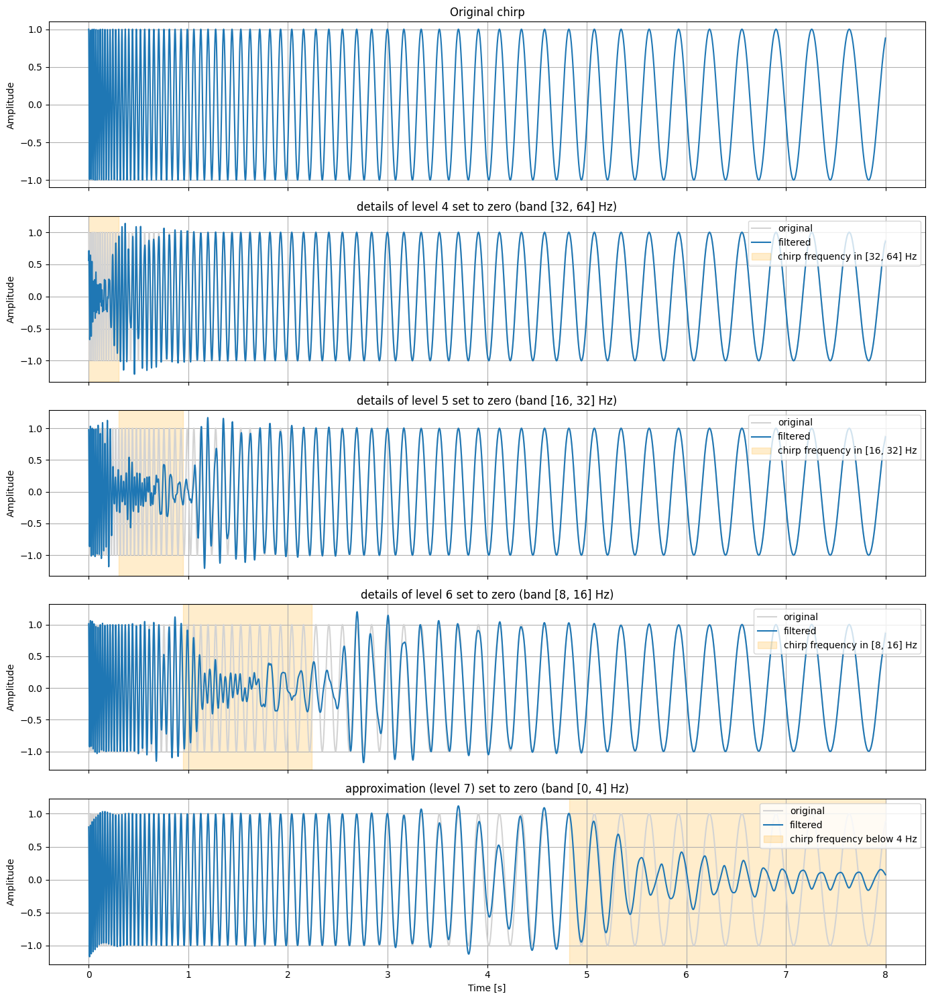

In [10]:
def inst_freq(t, f0=60, f1=2, t1=10):
    # instantaneous frequency of the hyperbolic chirp generated above
    return f0 * f1 * t1 / ((f0 - f1) * t + f1 * t1)


def time_in_band(f_low, f_high):
    # time interval during which the chirp frequency lies in [f_low, f_high]
    t_high = (60 * 2 * 10 / f_high - 20) / 58
    t_low = (60 * 2 * 10 / f_low - 20) / 58
    return max(t_high, 0), min(t_low, t[-1])


wavelet = "sym8"
J = 7
coeff = pywt.wavedec(x, wavelet, level=J)
bands = {k: (Fs / 2 ** (J - k + 2), Fs / 2 ** (J - k + 1)) for k in range(1, J + 1)}  # coeff[k] -> detail band
bands[0] = (0, Fs / 2 ** (J + 1))

fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)
axes[0].plot(t, x)
axes[0].set_title("Original chirp")
for ax, k in zip(axes[1:], [4, 3, 2, 0]):
    nulled = [c.copy() for c in coeff]
    nulled[k] = np.zeros_like(nulled[k])
    x_filt = pywt.waverec(nulled, wavelet)[: x.size]
    f_low, f_high = bands[k]
    name = "approximation (level %d)" % J if k == 0 else "details of level %d" % (J - k + 1)
    ax.plot(t, x, color="lightgray", label="original")
    ax.plot(t, x_filt, label="filtered")
    if k != 0:
        ta, tb = time_in_band(f_low, f_high)
        ax.axvspan(ta, tb, color="orange", alpha=0.2, label="chirp frequency in [%.0f, %.0f] Hz" % (f_low, f_high))
    else:
        ta, tb = time_in_band(1e-3, f_high)
        ax.axvspan(ta, tb, color="orange", alpha=0.2, label="chirp frequency below %.0f Hz" % f_high)
    ax.set_title("%s set to zero (band [%.0f, %.0f] Hz)" % (name, f_low, f_high))
    ax.legend(loc="upper right")
for ax in axes:
    ax.set_ylabel("Amplitude")
    ax.grid()
axes[-1].set_xlabel("Time [s]")
tight_layout()
show()

Since the frequency of the chirp decreases continuously, each octave of the wavelet transform "sees" the chirp during a specific time interval: its frequency lies in [32, 64] Hz for $t <$ 0.30 s, in [16, 32] Hz for 0.30 s $< t <$ 0.95 s, in [8, 16] Hz for 0.95 s $< t <$ 2.24 s, and below 4 Hz after 4.8 s (orange areas).

Setting one detail level to zero removes the chirp **precisely during the corresponding time interval**, and leaves the rest of the signal unchanged: the wavelet transform is localised both in time and in frequency, so filtering an octave acts on a time-frequency region. Similarly, setting the approximation of level 7 to zero removes the end of the signal, where the frequency is below 4 Hz. The removal is not perfect: a residual oscillation of 20 to 30 % of the amplitude remains in the removed interval, and the transitions are progressive, because the wavelet filters are not ideal band-pass filters (their bands overlap near $F_s/2^j$).

Note that zeroing the details acts as a **band-stop** filter on one octave, zeroing all the finest details (question 4) acts as a low-pass filter, and zeroing the approximation acts as a high-pass filter.

**Question 3.** Same filtering (details of level 5, band [16, 32] Hz, set to zero) with wavelets of increasing length. The residual energy of the chirp in the removed time interval measures how well the octave has been removed.

haar   filter length   2: residual RMS amplitude in the removed interval = 68.3 %
db2    filter length   4: residual RMS amplitude in the removed interval = 59.3 %
sym8   filter length  16: residual RMS amplitude in the removed interval = 32.5 %
coif5  filter length  30: residual RMS amplitude in the removed interval = 25.4 %
dmey   filter length  62: residual RMS amplitude in the removed interval = 21.3 %


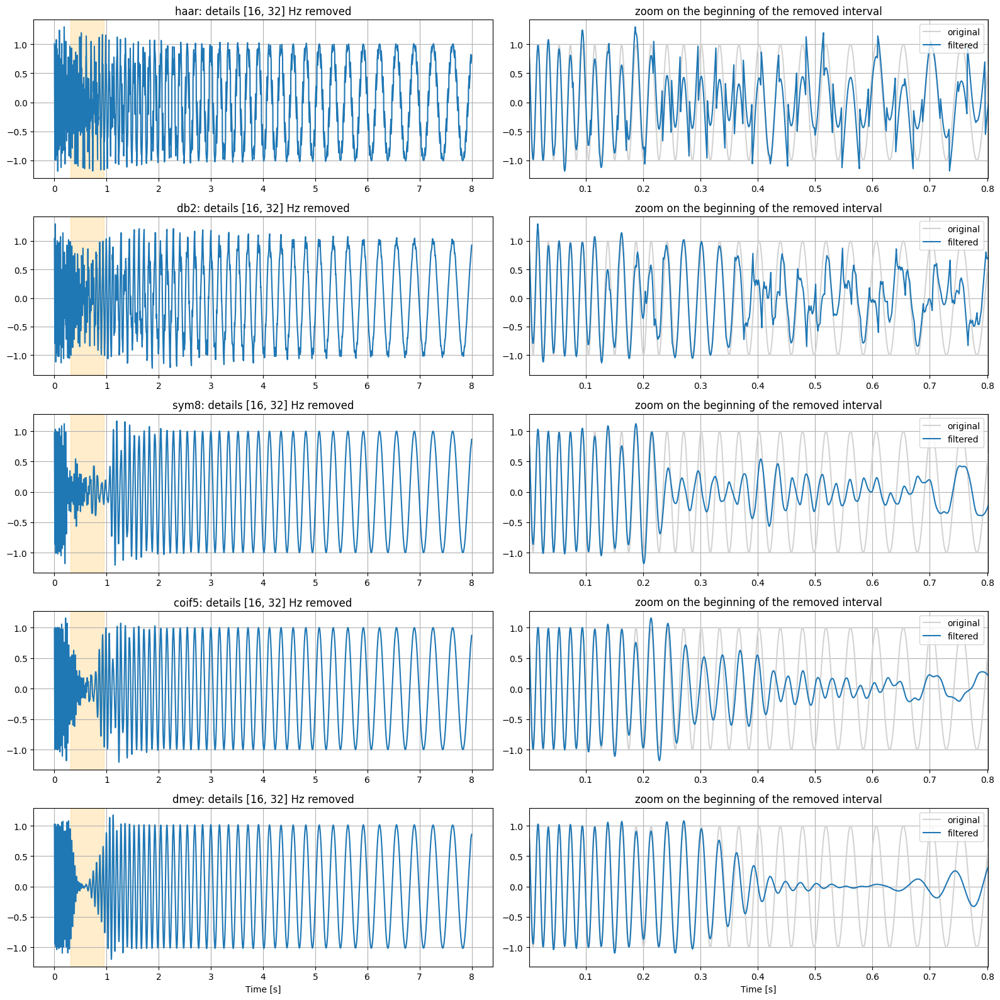

In [11]:
wavelets = ["haar", "db2", "sym8", "coif5", "dmey"]
k = 3  # coeff[3] = details of level 5 (band [16, 32] Hz)
f_low, f_high = bands[k]
ta, tb = time_in_band(f_low, f_high)
inside = (t > ta + 0.1) & (t < tb - 0.1)

fig, axes = plt.subplots(len(wavelets), 2, figsize=(16, 3.2 * len(wavelets)))
for r, wavelet in enumerate(wavelets):
    coeff_w = pywt.wavedec(x, wavelet, level=J)
    coeff_w[k] = np.zeros_like(coeff_w[k])
    x_filt = pywt.waverec(coeff_w, wavelet)[: x.size]
    residual = np.sqrt(np.mean(x_filt[inside] ** 2) / np.mean(x[inside] ** 2))
    print("%-6s filter length %3d: residual RMS amplitude in the removed interval = %4.1f %%"
          % (wavelet, pywt.Wavelet(wavelet).dec_len, 100 * residual))
    axes[r, 0].plot(t, x_filt)
    axes[r, 0].axvspan(ta, tb, color="orange", alpha=0.2)
    axes[r, 0].set_title("%s: details [%.0f, %.0f] Hz removed" % (wavelet, f_low, f_high))
    axes[r, 1].plot(t, x, color="lightgray", label="original")
    axes[r, 1].plot(t, x_filt, label="filtered")
    axes[r, 1].set_xlim(ta - 0.3, ta + 0.5)
    axes[r, 1].set_title("zoom on the beginning of the removed interval")
    axes[r, 1].legend(loc="upper right")
    for ax in axes[r]:
        ax.grid()
axes[-1, 0].set_xlabel("Time [s]")
axes[-1, 1].set_xlabel("Time [s]")
tight_layout()
show()

The same octave ([16, 32] Hz, i.e. 0.30 s $< t <$ 0.95 s) has been removed with wavelets of increasing filter length:

| wavelet | filter length | residual amplitude in the removed interval |
| --- | --- | --- |
| `haar` | 2 | 68 % |
| `db2` | 4 | 59 % |
| `sym8` | 16 | 32 % |
| `coif5` | 30 | 25 % |
| `dmey` | 62 | 21 % |

With the **Haar** wavelet the filtering is very poor: most of the chirp is still present in the removed interval, and the whole signal is distorted by small steps and spikes, even far from the removed band. Its filters are extremely short, so their frequency responses are very wide: the bands of successive octaves overlap strongly, and removing one level does not remove one octave but degrades the neighbouring ones (aliasing between bands is no longer compensated at reconstruction). `db2` is only slightly better.

With longer, smoother wavelets (`sym8`, `coif5`, `dmey`) the filters are more selective in frequency: the octave is removed much more cleanly and the rest of the signal is preserved. The price is a lower time localisation: the transition at the edges of the removed interval spreads over a longer duration (about 0.1 s for `dmey`), since a longer filter mixes more samples.

This is the compromise mentioned in the introduction of the lab: more null moments and longer filters give a better frequency selectivity and a sparser representation of smooth signals, while short wavelets localise better in time and suit signals with discontinuities.

**Question 4.** Two other signals of `pywt.data`: `Bumps` (sharp localised peaks) and `Doppler` (oscillation whose frequency decreases with time). The three finest detail levels are set to zero, with a short (`haar`) and a long (`sym8`) wavelet.

Bumps, haar: relative RMS error after removing the 3 finest detail levels = 10.1 %
Bumps, sym8: relative RMS error after removing the 3 finest detail levels = 4.5 %


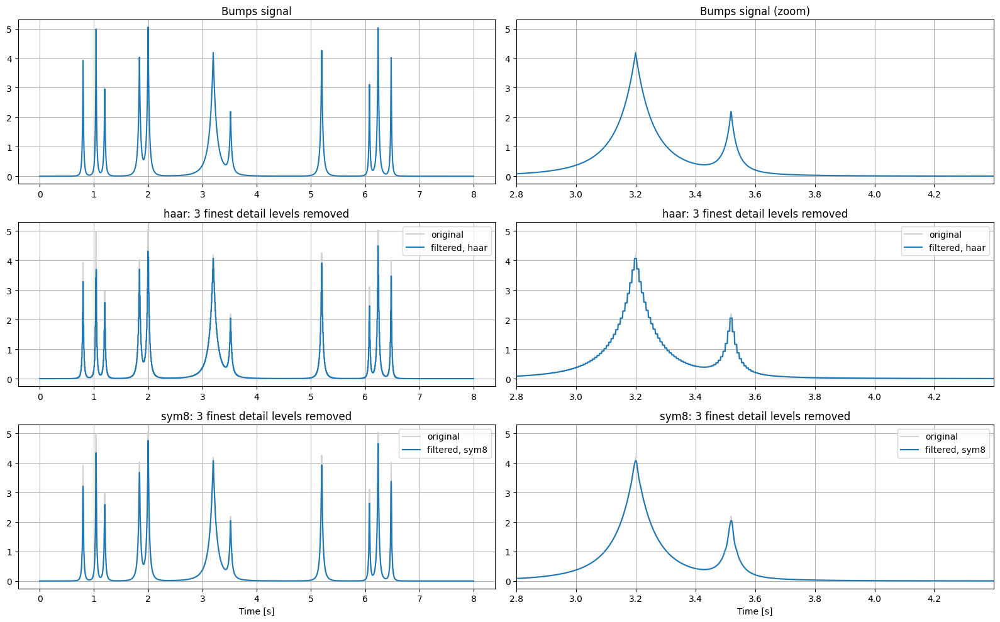

Doppler, haar: relative RMS error after removing the 3 finest detail levels = 3.4 %
Doppler, sym8: relative RMS error after removing the 3 finest detail levels = 0.2 %


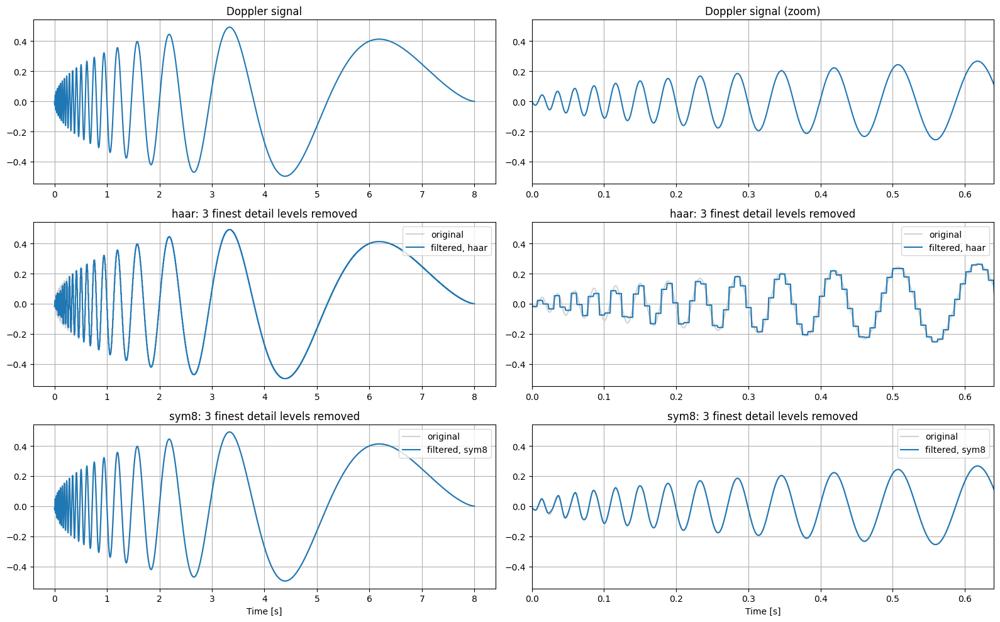

In [12]:
signals = {name: pywt.data.demo_signal(name=name, n=N) for name in ["Bumps", "Doppler"]}
wavelets = ["haar", "sym8"]
levels_removed = 3  # the 3 finest detail levels

for name, s in signals.items():
    fig, axes = plt.subplots(len(wavelets) + 1, 2, figsize=(16, 10))
    zoom = (0.35, 0.55) if name == "Bumps" else (0.0, 0.08)
    for col in range(2):
        axes[0, col].plot(t, s)
        axes[0, col].set_title("%s signal" % name + ("" if col == 0 else " (zoom)"))
    for r, wavelet in enumerate(wavelets, start=1):
        coeff_s = pywt.wavedec(s, wavelet, level=5)
        for j in range(1, levels_removed + 1):
            coeff_s[-j] = np.zeros_like(coeff_s[-j])
        s_filt = pywt.waverec(coeff_s, wavelet)[: s.size]
        err = np.sqrt(np.mean((s_filt - s) ** 2)) / np.sqrt(np.mean(s ** 2))
        print("%s, %s: relative RMS error after removing the %d finest detail levels = %.1f %%"
              % (name, wavelet, levels_removed, 100 * err))
        for col in range(2):
            axes[r, col].plot(t, s, color="lightgray", label="original")
            axes[r, col].plot(t, s_filt, label="filtered, " + wavelet)
            axes[r, col].legend(loc="upper right")
            axes[r, col].set_title("%s: %d finest detail levels removed" % (wavelet, levels_removed))
    for r in range(len(wavelets) + 1):
        axes[r, 1].set_xlim(zoom[0] * t[-1], zoom[1] * t[-1])
        for col in range(2):
            axes[r, col].grid()
    for col in range(2):
        axes[-1, col].set_xlabel("Time [s]")
    tight_layout()
    show()

Removing the 3 finest detail levels acts as an approximate low-pass filter: it mainly keeps content below about 64 Hz. Because the wavelet filters have transition bands, this is not an ideal cut-off at exactly 64 Hz.

- **Bumps** (sharp peaks): the broad parts of the peaks are preserved, but the **tops of the sharpest peaks are cut** (their fast variations belong to the fine scales), for instance the peak near 1 s drops from 5 to about 3.7 with `haar` and 4.4 with `sym8`. With `haar`, the reconstruction is made of **steps** of $2^3$ = 8 samples, since the Haar approximation is piecewise constant: relative error 10.1 %. With `sym8`, the peaks are smooth and better preserved (4.5 %), with only a slight rounding of their tips.
- **Doppler** (oscillation whose frequency decreases with time): only the **very beginning** of the signal, where the frequency is higher than 64 Hz, is removed; the rest is almost unchanged. Again `haar` produces a staircase approximation of the oscillations (3.4 % error), whereas `sym8` reproduces them almost perfectly (0.2 %).

The conclusions of questions 2 and 3 are thus confirmed on other signals: removing fine scales smooths the signal locally where it varies fast, and the choice of the wavelet determines the artefacts. Smooth wavelets with several null moments (`sym8`) are better suited to smooth or oscillating signals, while the Haar wavelet introduces blocky artefacts on everything which is not piecewise constant.

## 2D discrete wavelet transform

We now turn to the computation of a 2D wavelet transform to analyze images (example images are available in the `img/` folder). Let us start with a simple chessboard image.

*Indication: you can consider other images, in particular using* `pywt.data` *.*

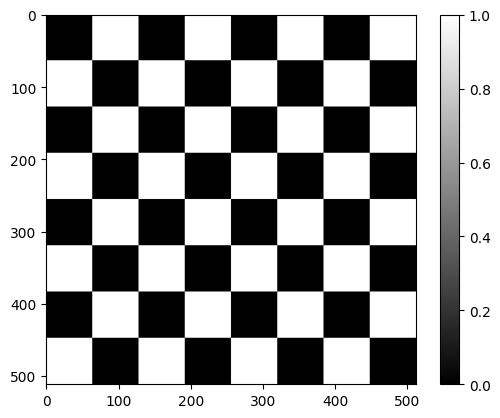

In [13]:
filename = "img/chessboard.png"

I = mpimg.imread(filename)

plt.figure()
plt.imshow(I, cmap="gray")
plt.colorbar()
plt.show()

#### Wavelet transform

We first compute a 2D wavelet transform using the function `pywt.wavedec2` and display the results.

In [14]:
# Wavelet decomposition
Jmax = int(np.log2(I.shape[0]))  # maximal number of octaves
print("Jmax=" + str(Jmax))
J = 2

wtcoeffs = pywt.wavedec2(I, wavelet="sym8", level=J, mode="periodization")

Jmax=9


Since the coefficients are stored in a dictionary of objects, we need to convert these into an array for obtain a graphical representation using the `plot_wavelet` function.

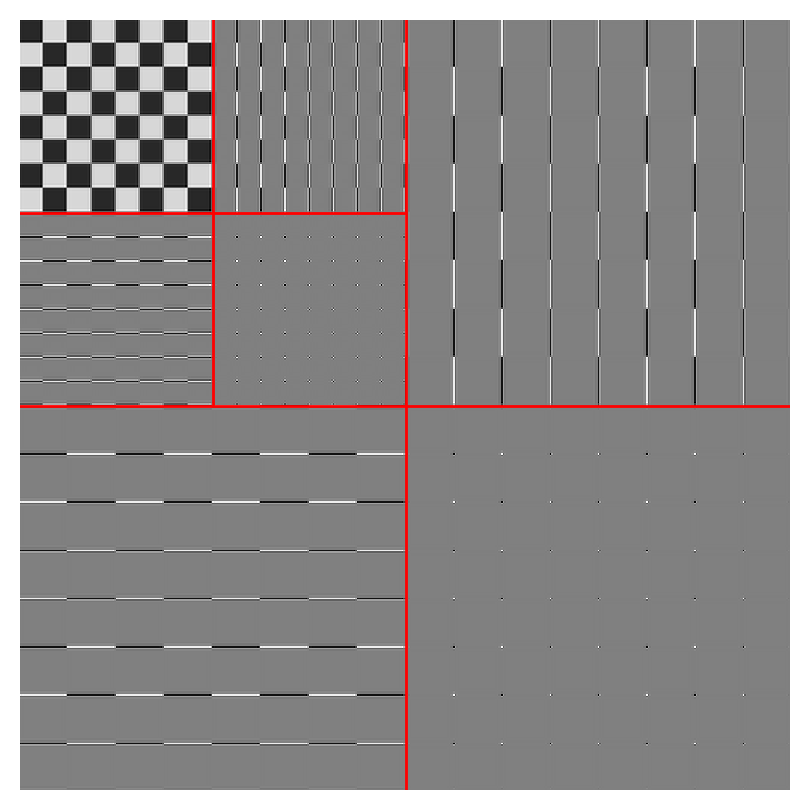

In [15]:
# Casting coeff in a single array
wtcoeffs_arr, coeff_slices = pywt.coeffs_to_array(wtcoeffs)

# Graphical representation
plt.figure(figsize=(5, 5), dpi=200)
plot_wavelet(wtcoeffs_arr, Jmin=Jmax - J);

## Exercise 2

1. Observe the figure above and briefly recall its structure and what it represents.
2. Play with the parameter $J$ (corresponding to the optional parameter `level` from `pywt.wavedec2`). What does it correspond to?
3. Observe the wavelet transform of other images.
4. For the checkerboard image, try the Haar wavelet and compare the result with any other wavelet transform. What do you notice? Do you have an explanation?

### Answers to Exercise 2

**Question 1.** To identify the orientations, the one-level transform of a small test image containing only a horizontal band (horizontal edges) is displayed with the same layout.

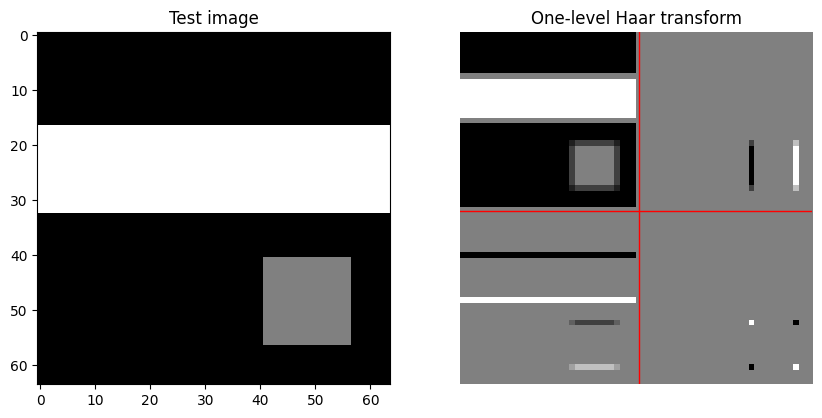

cH (horizontal details) is stored in the lower-left block, cV (vertical details) in the upper-right block.


In [16]:
test = np.zeros((64, 64))
test[17:33, :] = 1  # horizontal band: only horizontal edges
test[41:57, 41:57] = 0.5  # small square: horizontal and vertical edges
test_coeffs = pywt.wavedec2(test, wavelet="haar", level=1, mode="periodization")
test_arr, _ = pywt.coeffs_to_array(test_coeffs)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(test, cmap="gray")
axes[0].set_title("Test image")
plt.sca(axes[1])
plot_wavelet(test_arr, Jmin=int(np.log2(64)) - 1)
axes[1].set_title("One-level Haar transform")
show()
print("cH (horizontal details) is stored in the lower-left block, cV (vertical details) in the upper-right block.")

The figure is the array of wavelet coefficients of the image, displayed with the dyadic layout of `pywt.coeffs_to_array` (each block is rescaled separately for display, grey = 0):

- the **upper-left** block of size $512/2^J$ is the **approximation** at the coarsest scale $J$: a low-resolution version of the image (here a smaller chessboard);
- around it, each level $j$ (from $J$ down to 1, the finest level being the largest blocks) contains three blocks of details of size $512/2^j$:
    - **lower-left**: the **horizontal details** `cH` (high-pass along the rows, low-pass along the columns), which respond to horizontal edges, as shown by the test image above where the horizontal band only produces coefficients in this block;
    - **upper-right**: the **vertical details** `cV`, which respond to vertical edges;
    - **lower-right**: the **diagonal details** `cD` (high-pass in both directions), which respond to corners and oblique structures.

For the chessboard, the horizontal details show horizontal lines (the horizontal borders of the squares), the vertical details show vertical lines, and the diagonal details are non-zero only at the corners of the squares. Everywhere else, inside the squares, the image is constant and the details are zero: the wavelet representation of this image is very sparse.

**Question 2.** Transform of the chessboard for $J$ = 1 to 4 (`sym8`).

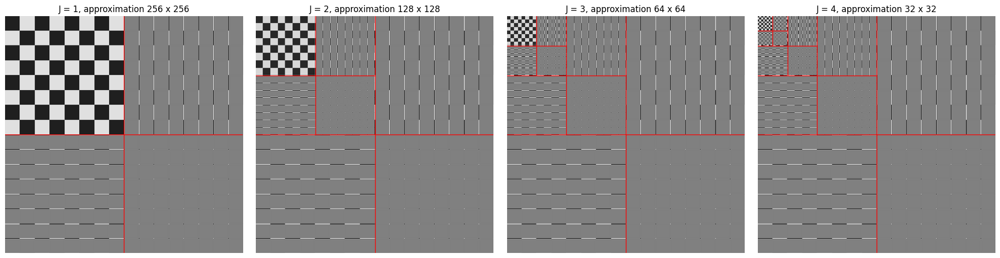

In [17]:
filename = "img/chessboard.png"
I = mpimg.imread(filename)
Jmax = int(np.log2(I.shape[0]))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, J in zip(axes, [1, 2, 3, 4]):
    wtcoeffs = pywt.wavedec2(I, wavelet="sym8", level=J, mode="periodization")
    wtcoeffs_arr, coeff_slices = pywt.coeffs_to_array(wtcoeffs)
    plt.sca(ax)
    plot_wavelet(wtcoeffs_arr, Jmin=Jmax - J)
    ax.set_title("J = %d, approximation %d x %d" % (J, wtcoeffs[0].shape[0], wtcoeffs[0].shape[1]))
tight_layout()
show()

$J$ is the **number of decomposition levels** (octaves): `wavedec2` applies the one-level 2D transform $J$ times, each time on the previous approximation. Increasing $J$ by one splits the current approximation into a new approximation of half the size in each direction plus three blocks of details: for $J$ = 1, 2, 3, 4 the approximation is 256, 128, 64 and 32 pixels wide. The detail blocks already computed are unchanged.

$J$ therefore sets the coarsest scale analysed, $2^J$ pixels. It can go up to $J_{max} = \log_2(512)$ = 9 in theory, but in practice it is limited by the length of the filters: when the approximation becomes shorter than the filter, all coefficients are affected by boundary effects (PyWavelets issues a warning). For the chessboard, whose squares are 64 pixels wide, the approximation remains a recognisable chessboard up to $J$ = 6; beyond, the squares are smaller than the scale of analysis and their content moves into the details.

**Question 3.** Wavelet transforms ($J$ = 3, `sym8`) of the two natural images of the folder. Pixel values are converted to floats in [0, 1].

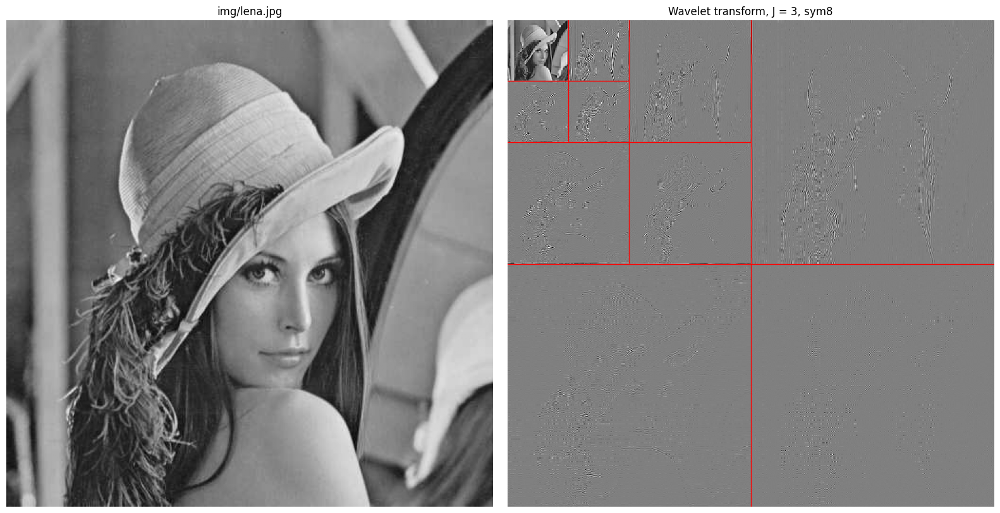

img/lena.jpg: energy of the approximation = 98.94 %, horizontal / vertical / diagonal details = 0.223 / 0.680 / 0.155 %


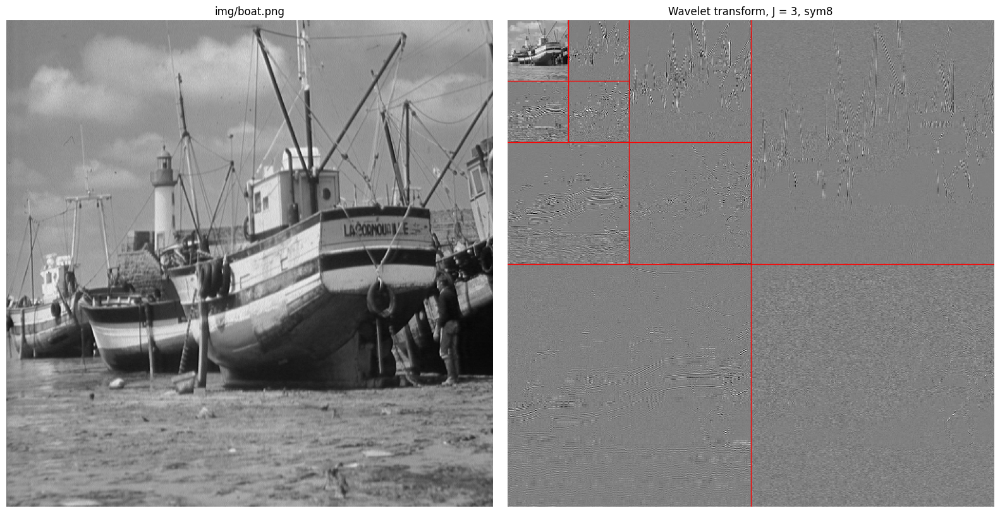

img/boat.png: energy of the approximation = 98.30 %, horizontal / vertical / diagonal details = 0.511 / 1.043 / 0.148 %


In [18]:
def load_gray(filename):
    # grey-level image as a float array in [0, 1], whatever the file format
    img = mpimg.imread(filename).astype(float)
    if img.ndim == 3:
        img = img[..., :3].mean(axis=2)
    if img.max() > 1:
        img = img / 255
    return img


J = 3
for filename in ["img/lena.jpg", "img/boat.png"]:
    img = load_gray(filename)
    coeffs_img = pywt.wavedec2(img, wavelet="sym8", level=J, mode="periodization")
    arr, _ = pywt.coeffs_to_array(coeffs_img)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title(filename)
    axes[0].axis("off")
    plt.sca(axes[1])
    plot_wavelet(arr, Jmin=int(np.log2(img.shape[0])) - J)
    axes[1].set_title("Wavelet transform, J = %d, sym8" % J)
    tight_layout()
    show()

    # proportion of the energy of the details in each orientation
    energies = np.zeros(3)
    for level in coeffs_img[1:]:
        energies += [np.sum(d ** 2) for d in level]
    total = np.sum(coeffs_img[0] ** 2) + energies.sum()
    print("%s: energy of the approximation = %.2f %%, horizontal / vertical / diagonal details = %.3f / %.3f / %.3f %%"
          % (filename, 100 * np.sum(coeffs_img[0] ** 2) / total, *(100 * energies / total)))

For both natural images, the approximation contains almost all the energy (98 to 99 %), and the detail coefficients are **close to zero everywhere except along edges and in textured regions**: this sparsity is what makes wavelets efficient for compression and denoising.

- **Lena**: the details concentrate on the contours of the hat and of the shoulder, on the edge of the mirror frame on the right, and above all in the **feathers and hair**, which form a dense texture. The vertical details (upper-right blocks) contain more energy (0.68 %) than the horizontal ones (0.22 %): the long vertical structures (hair, frame of the mirror, vertical structures of the background) dominate. The finest level contains little information, the image being rather smooth at the pixel scale.
- **Boat**: the vertical details are dominated by the **masts, ropes and the lighthouse** (1.04 % of the energy), the horizontal details by the **stripes of the hulls, the waterline and the roofs** (0.51 %), and the diagonal details by the oblique ropes. The finest diagonal level looks like noise: it captures the fine grain of the photograph and the texture of the sand.

Each orientation block thus acts as an edge detector for one direction and one scale.

**Question 4.** Haar wavelet versus longer wavelets on the chessboard ($J$ = 3).

haar :      0 non-zero detail coefficients out of 258048 (0.00 %)
db2  :  15104 non-zero detail coefficients out of 258048 (5.85 %)
sym8 :  80256 non-zero detail coefficients out of 258048 (31.10 %)


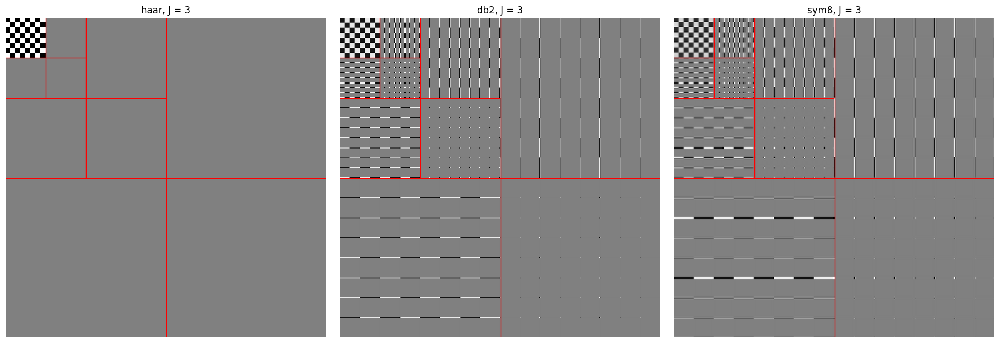

In [19]:
I = mpimg.imread("img/chessboard.png")
J = 3
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, wavelet in zip(axes, ["haar", "db2", "sym8"]):
    wtcoeffs = pywt.wavedec2(I, wavelet=wavelet, level=J, mode="periodization")
    wtcoeffs_arr, _ = pywt.coeffs_to_array(wtcoeffs)
    details = np.concatenate([d.ravel() for level in wtcoeffs[1:] for d in level])
    n_nonzero = np.sum(np.abs(details) > 1e-6)
    print("%-5s: %6d non-zero detail coefficients out of %d (%.2f %%)"
          % (wavelet, n_nonzero, details.size, 100 * n_nonzero / details.size))
    plt.sca(ax)
    plot_wavelet(wtcoeffs_arr, Jmin=Jmax - J)
    ax.set_title("%s, J = %d" % (wavelet, J))
tight_layout()
show()

With the **Haar wavelet, all the detail coefficients of the chessboard are exactly zero** (0 non-zero coefficients out of 258048), whereas `db2` gives 5.9 % and `sym8` 31 % of non-zero detail coefficients, located along the edges of the squares, with oscillations (positive and negative values) around each edge.

Explanation: the Haar scaling function is the indicator of an interval of length $2^j$, so the Haar approximation spaces contain exactly the images that are **piecewise constant on dyadic squares**. The chessboard is piecewise constant on squares of $64 = 2^6$ pixels whose borders fall on multiples of 64, i.e. on the dyadic grid of every level $j \leq 6$: at each level, every $2 \times 2$ block of the approximation lies entirely inside one square, so all the differences computed by the Haar wavelet vanish. The image belongs to the approximation space and is represented perfectly by the approximation alone.

Longer wavelets have a support that straddles the edges (16 coefficients for `sym8`), so each discontinuity produces non-zero details over several coefficients at each scale. Haar is thus optimal for this very particular image, but it would give no zero details if the squares were shifted by one pixel (Haar is not translation invariant, see Exercise 5), and it is a poor choice for smooth natural images.

**Remark:** a 2D wavelet transform is a succession of two 1D DWT. If we consider only 1 step of the multiresolution hierarchy we get:

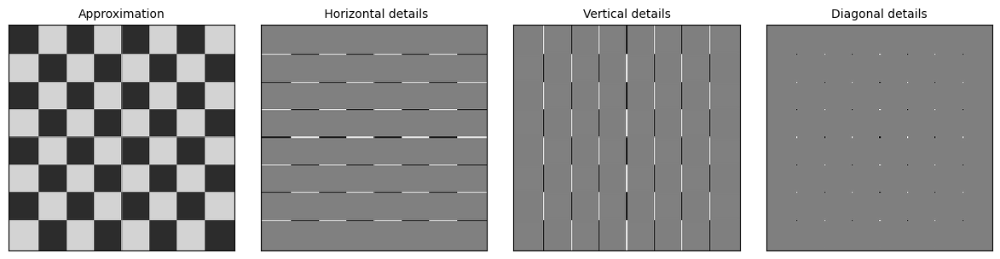

In [20]:
coeffs2 = pywt.dwt2(I, "sym8")

LL, (LH, HL, HH) = coeffs2

fig = plt.figure(figsize=(12, 3))
titles = [
    "Approximation",
    " Horizontal details",
    "Vertical details",
    "Diagonal details",
]
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()

## Wavelet filtering

This section illustrates a filtering procedure conducted in the wavelet domain. The purpose is to observe that one can filter an image both at a given scale, for specific orientations, and at chosen places on top.

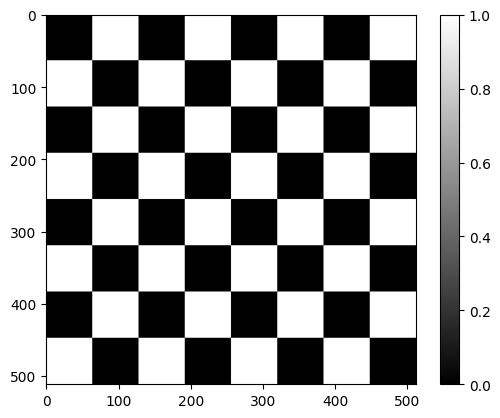

In [21]:
filename = "img/chessboard.png"
I = mpimg.imread(filename)


plt.figure()
plt.imshow(I, cmap="gray")
plt.colorbar()
plt.show()

#### First steps for filtering

We will first use a 1 step decomposition and put some coefficients to zero.

In [22]:
coeffs2 = pywt.dwt2(I, "db4")

In [23]:
LL, (LH, HL, HH) = coeffs2

In [24]:
L = 8
LL[2 ** (L - 1) : 2 ** L + 1, 2 ** (L - 1) : 2 ** L + 1] = 0

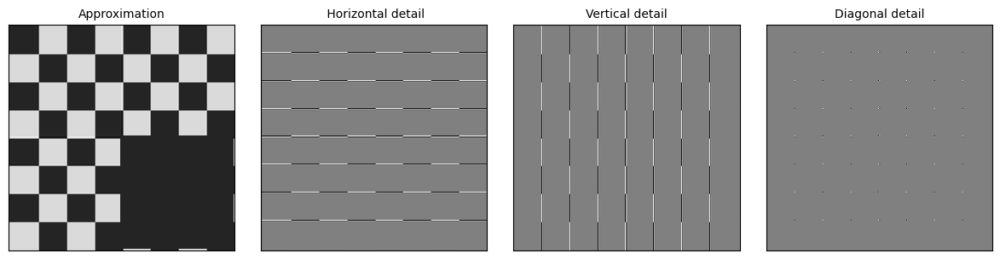

In [25]:
LL, (LH, HL, HH) = coeffs2
fig = plt.figure(figsize=(12, 3))
titles = ["Approximation", " Horizontal detail", "Vertical detail", "Diagonal detail"]
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()

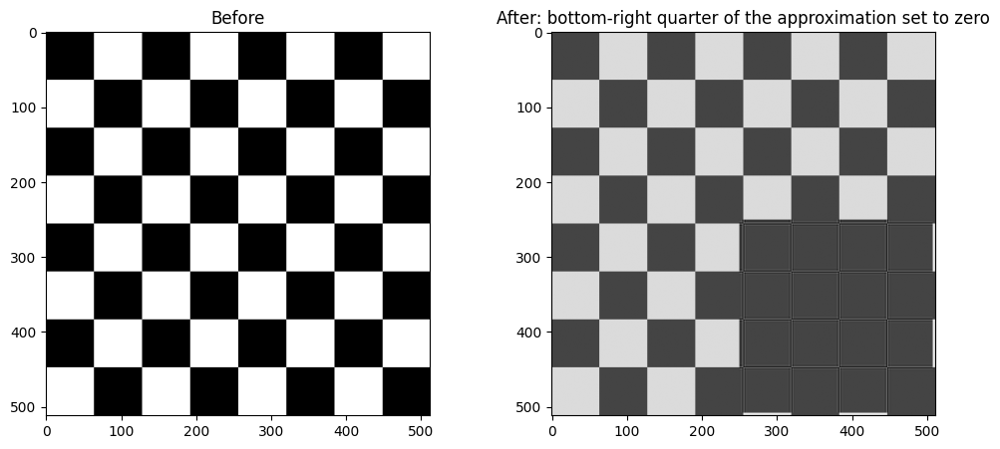

In [26]:
I_d = pywt.idwt2(coeffs2, "db4")
fig = plt.figure(figsize=(12, 5))
subplot(121)
plt.imshow(I, cmap="gray")
title("Before")
subplot(122)
plt.imshow(I_d, cmap="gray")
title("After: bottom-right quarter of the approximation set to zero")
plt.show()

## Exercise 3

1. Read the documentation of the `pywt.wavedec2` and `pywt.waverec2` functions to understand how to easily access any set of coefficients for a given scale and orientation.
2. Play with wavelet filtering procedure described above by setting some sets of coefficients to zero (approximation or details of various orientations). Illustrate its result with the `chessboard.png` image.
3. Do the same with any gray level image of your choice (see `img\` folder).
4. Observe and comment.

### Answers to Exercise 3

**Question 1.** `pywt.wavedec2(img, wavelet, level=J)` returns a list `coeffs = [cA_J, (cH_J, cV_J, cD_J), (cH_{J-1}, cV_{J-1}, cD_{J-1}), ..., (cH_1, cV_1, cD_1)]`:

- `coeffs[0]` is the approximation at the coarsest scale $J$;
- `coeffs[k]`, for $k = 1, \dots, J$, is the tuple of details of level $J - k + 1$ (so `coeffs[1]` is the coarsest level and `coeffs[-1]` the finest), in the order horizontal, vertical, diagonal;
- inside each array, the coefficient `[p, q]` of level $j$ corresponds to the region of the image around pixel $(2^j p, 2^j q)$.

`pywt.waverec2(coeffs, wavelet)` performs the inverse multilevel transform and returns the image. To filter, one computes `wavedec2`, modifies a **copy** of the chosen arrays (a scale, an orientation, and possibly a spatial region), and reconstructs with `waverec2`. The function below implements this procedure and is used for questions 2 and 3.

In [27]:
def filter_wavelet(img, wavelet, J, keep_approx=True, remove=(), levels=None, region=None):
    # Wavelet filtering of an image.
    #   remove : orientations to set to zero among "H" (horizontal), "V" (vertical), "D" (diagonal)
    #   levels : detail levels concerned (1 = finest); all levels if None
    #   region : (row_min, row_max, col_min, col_max) in relative coordinates [0, 1]; whole image if None
    coeffs_f = pywt.wavedec2(img, wavelet=wavelet, level=J, mode="periodization")
    coeffs_f = [coeffs_f[0].copy()] + [tuple(d.copy() for d in level) for level in coeffs_f[1:]]
    if not keep_approx:
        coeffs_f[0][:] = 0
    for k in range(1, J + 1):
        level = J - k + 1  # coeffs_f[k] contains the details of level J - k + 1
        if levels is not None and level not in levels:
            continue
        for o, d in zip("HVD", coeffs_f[k]):
            if o in remove:
                if region is None:
                    d[:] = 0
                else:
                    r0, r1, c0, c1 = region
                    d[int(r0 * d.shape[0]):int(r1 * d.shape[0]), int(c0 * d.shape[1]):int(c1 * d.shape[1])] = 0
    return pywt.waverec2(coeffs_f, wavelet, mode="periodization")


experiments = [
    ("all horizontal details removed", dict(remove="H")),
    ("all vertical details removed", dict(remove="V")),
    ("all details removed (approximation only)", dict(remove="HVD")),
    ("approximation removed (details only)", dict(keep_approx=False)),
    ("horizontal + vertical details removed in the left half", dict(remove="HV", region=(0, 1, 0, 0.5))),
    ("fine details (levels 1-2) removed", dict(remove="HVD", levels=(1, 2))),
    ("all diagonal details removed", dict(remove="D")),
]


def show_experiments(img, wavelet, J, title_img, zoom=None):
    # zoom: (row slice, column slice) displayed; whole image if None
    zoom = (slice(None), slice(None)) if zoom is None else zoom
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()
    axes[0].imshow(img[zoom], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(title_img)
    for ax, (label, kwargs) in zip(axes[1:], experiments):
        out = filter_wavelet(img, wavelet, J, **kwargs)[zoom]
        if kwargs.get("keep_approx", True):
            ax.imshow(out, cmap="gray", vmin=0, vmax=1)
        else:
            ax.imshow(out, cmap="gray")  # details only: zero mean, automatic scale
        ax.set_title(label, fontsize=10)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle("%s: wavelet filtering with %s, J = %d" % (title_img, wavelet, J))
    tight_layout()
    show()

**Question 2.** Chessboard, with the `db4` wavelet (with the Haar wavelet all the details of the chessboard are zero, so removing them would change nothing, see Exercise 2).

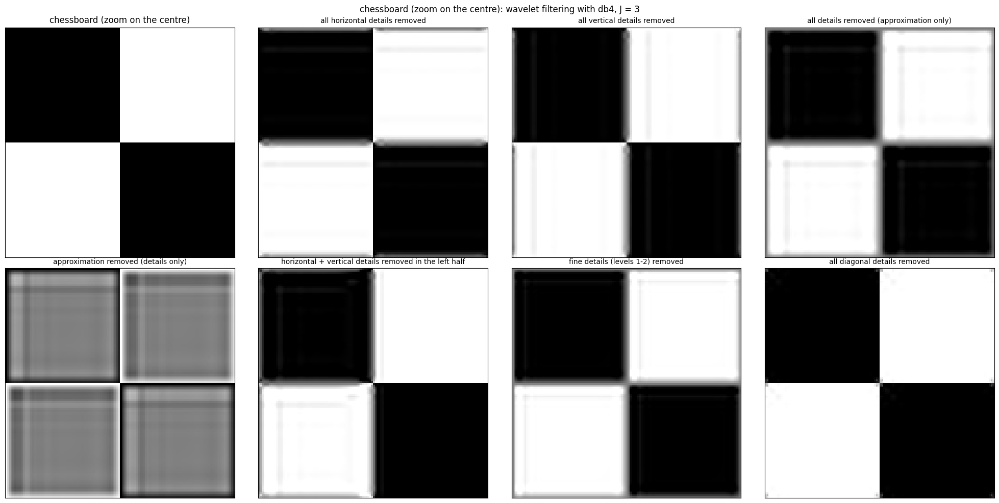

In [28]:
I = mpimg.imread("img/chessboard.png")
show_experiments(I, "db4", 3, "chessboard (zoom on the centre)", zoom=(slice(192, 320), slice(192, 320)))

Zoom on the centre of the chessboard (4 squares, vertical line at column 256 = boundary of the "left half" region). Grey levels are displayed on the same scale as the original image, except for the image of details only.

- **Horizontal details removed**: the **horizontal edges become blurred** (smooth vertical transitions between black and white) while the vertical edges stay sharp. **Vertical details removed**: the opposite. Removing one orientation thus smooths the image in one direction only.
- **All details removed**: only the approximation of level 3 remains, i.e. the chessboard seen at a resolution of $2^3$ = 8 pixels: all edges are blurred, with a slight ringing due to the `db4` filters.
- **Approximation removed**: the image of details only is an **edge map**: its strongest values lie along the borders of the squares, with oscillations that decay towards the inside of the squares (ringing of the `db4` filters over a few multiples of $2^3$ pixels). Its mean is zero: the uniform grey levels of the squares belong to the approximation.
- **Details removed in the left half**: the edges are blurred only on the left of column 256 and remain sharp on the right: the filtering is **spatially localised**, which a Fourier filter cannot do.
- **Fine details (levels 1 and 2) removed**: the edges are only slightly blurred (over about 4 pixels), level 3 details still carry most of the contrast of the edges.
- **Instructor example above**: setting the bottom-right quarter of the approximation `LL[128:257, 128:257]` to zero turns the bottom-right quarter of the image into a uniform dark region, but the borders of the squares remain visible there as thin lines, since they are carried by the details, which were not modified.

**Question 3.** Same experiments on the boat image.

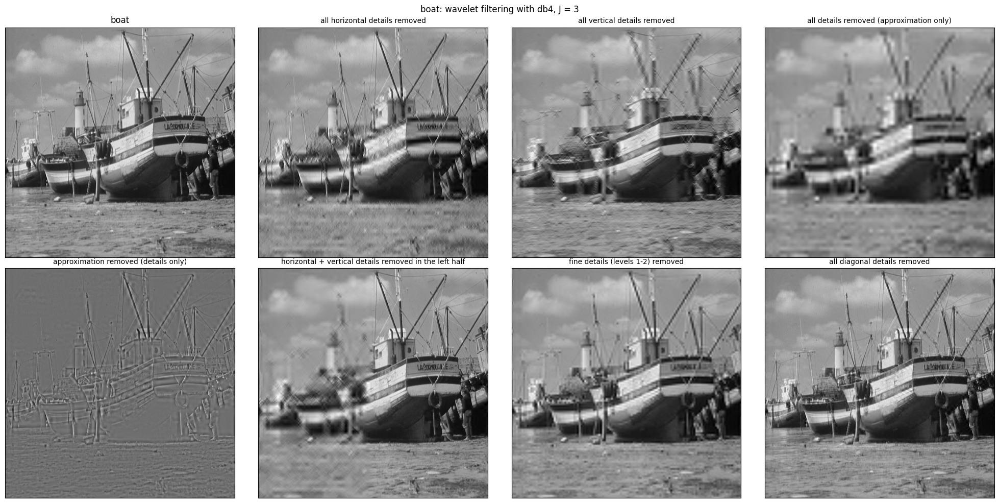

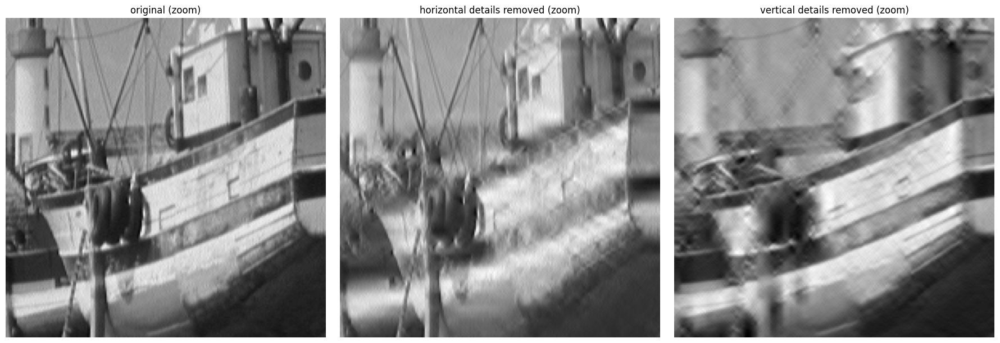

In [29]:
boat = load_gray("img/boat.png")
show_experiments(boat, "db4", 3, "boat")

# zoom on a detailed region to see the effect of the orientation
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
zoom = (slice(150, 350), slice(150, 350))
for ax, (label, kwargs) in zip(axes, [("original", None), ("horizontal details removed", dict(remove="H")),
                                     ("vertical details removed", dict(remove="V"))]):
    img = boat if kwargs is None else filter_wavelet(boat, "db4", 3, **kwargs)
    ax.imshow(img[zoom], cmap="gray")
    ax.set_title(label + " (zoom)")
    ax.axis("off")
tight_layout()
show()

**Question 4.** On the boat image, the effect of each operation is easy to interpret:

- **Horizontal details removed**: the **horizontal structures** (stripes of the hulls, window frames, roof lines, horizon) are blurred vertically, whereas the **masts and vertical ropes remain sharp**. **Vertical details removed**: the masts, the lighthouse and the vertical ropes become blurred horizontally, while the stripes of the hulls stay sharp. In both cases some blocky, oblique artefacts appear, because the remaining coefficients are no longer consistent with each other.
- **Diagonal details removed**: the image looks almost unchanged: diagonal details carry very little energy (0.15 %), mostly fine texture.
- **Approximation only**: a blurred image (resolution 8 pixels) in which the global shapes are preserved but all fine structures (ropes, letters of the name of the boat) are lost.
- **Details only**: an edge map of the image, where the contours of the boats, masts and ropes are clearly visible.
- **Left half**: only the left half of the image is blurred.
- **Fine details removed** (levels 1 and 2): a slight smoothing which removes the grain of the photograph and the finest ropes, while the rest remains sharp.

Overall, the wavelet domain allows **selective filtering in scale, orientation and position**. Since most of the energy of natural images is in the approximation and in a few large detail coefficients along edges, removing details mainly degrades edges and textures; this is the starting point of wavelet denoising, where only the *small* coefficients are removed.

## Wavelet Denoising

Wavelets are suitable for denoising signals which contain fast transients. In this context, thresholding can be used to cancel out the wavelet coefficients corresponding to regions where the signal varies smoothly. In these regions, the coefficients are expected to remain small (denoising is then provided by the low-pass cascade), and large wavelet coefficients (corresponding to large and fast transients of the signal) are preserved.

Let's simulate a noisy image to test the denoising procedure described above.

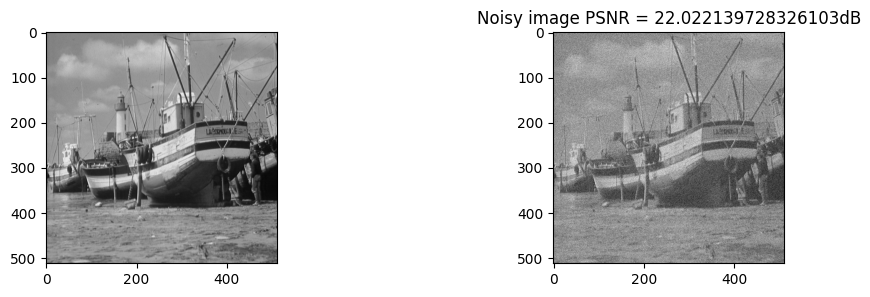

In [30]:
# The original image
filename = "img/boat.png"
I = mpimg.imread(filename)

I = I[:, :]
# The noise
sigma = 0.1  # noise level

[n, m] = I.shape
np.random.seed(0)  # fixed seed: same noise at each execution
noise = randn(n, m) * sigma  # randn = simulates normalized Gaussian random

# The noisy image
I_noisy = I + noise

# The PSNR quantifies the level of noise (see below for more explanations)
psnr1 = psnr(I, I_noisy, vmax=-1)


# Graphical representation
fig = plt.figure(figsize=(12, 3))
subplot(121)
plt.imshow(I, cmap="gray")
# plt.colorbar()
subplot(122)
plt.imshow(I_noisy, cmap="gray")
title("Noisy image PSNR = {}dB".format(psnr1))
# plt.colorbar()
plt.show()

#### Peak signal-to-noise ratio: definition

The peak signal-to-noise ratio (PSNR) is defined as the ratio between the maximum possible power of a signal and the power of the noise that affecting its representation. Since many signals have a very wide dynamic range, the PSNR is usually expressed in decibel scale (dB).

The PSNR is usually defined via the mean squared error (MSE). Given a noise-free $m \times n$ monochromatic image $I$ and its noisy approximation $K$, the MSE is defined as:

$$\mathrm{MSE} = \frac{1}{mn}\sum_{i=0}^{m-1}\sum_{j=0}^{n-1}[I(i,j)-K(i,j)]^2 = \frac{1}{mn}\|I-K\|_F^2.$$

The PSNR in decibel (dB) is defined as:

$$\begin{aligned}
\mathrm{PSNR} &= 10\log_{10}\left(\frac{\mathrm{MAX}_I^2}{\mathrm{MSE}}\right) && (1)\\
&= 20\log_{10}(\mathrm{MAX}_I) - 10\log_{10}(\mathrm{MSE}) && (2)
\end{aligned}$$

where $\mathrm{MAX}_I$ corresponds to the maximum possible value taken by a pixel of the image. When the pixels are represented using 8 bits per sample, this is 255. The lower the error, the higher the PSNR.

**Extension to color images**: for color images, with containing three values per pixel (RGB representation), the definition of the PSNR is the similar, except the MSE is the sum over all squared value differences (for each color, i.e. three times as many values as in a monochromatic image) divided by 3 times the image size.

### Thresholding

You can either use the `pywt.threshold` function, or a custom function as implemented below:

In [31]:
def perform_hardthresholding(f, thres):
    return f * (np.abs(f) > thres)

In [32]:
# Wavelet decomposition
Jmax = int(np.log2(I_noisy.shape[0]))  # maximal number of octaves
J = 5

coeffs = pywt.wavedec2(I_noisy, wavelet="sym8", level=J, mode="periodization")

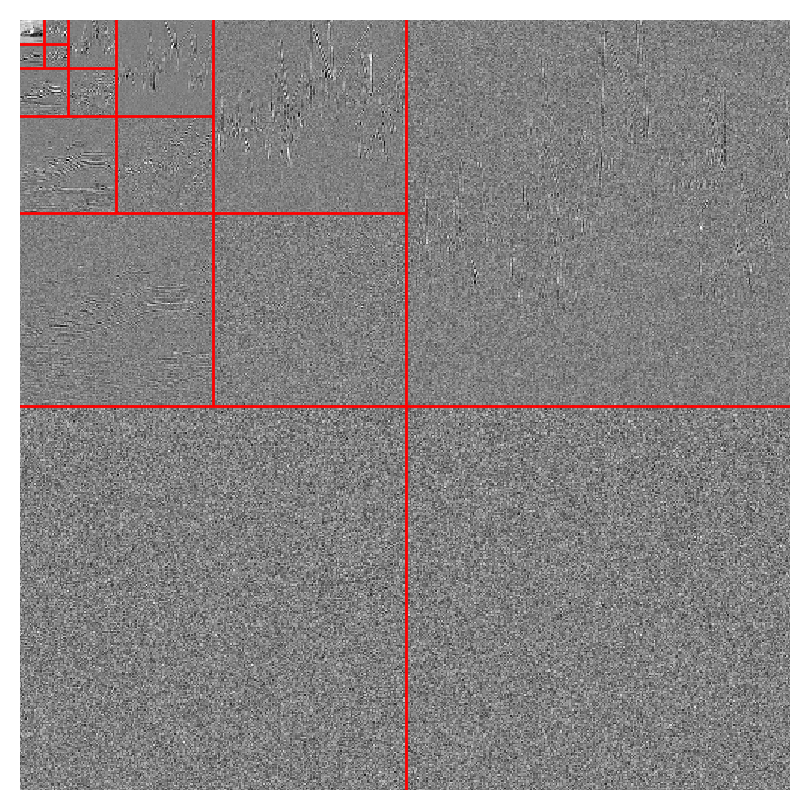

In [33]:
# Conversion to an array for graphical representation
coeffs_array, coeff_slices = pywt.coeffs_to_array(coeffs)

plt.figure(figsize=(5, 5), dpi=200)
plot_wavelet(coeffs_array, Jmin=Jmax - J);

In the following, we will keep the approximation coefficients unchanged, and only threshold details coefficients. Futher indications are provided below.

In [34]:
# Thresholding detail coefficients only (while preserving approximation coe
# 1) threshold all coefficients stored in an array
# 2) reset approx coefficients to their original value

thres = 2.0 * sigma
coeffs_arr_hard = perform_hardthresholding(coeffs_array, thres)

In [35]:
# convert the array of coeffcients to pywt coeffs
coeffs_hard = pywt.array_to_coeffs(coeffs_arr_hard, coeff_slices)
# Setting original approximation coefficients back
coeffs_hard[0] = coeffs[0]  # approximation preserved

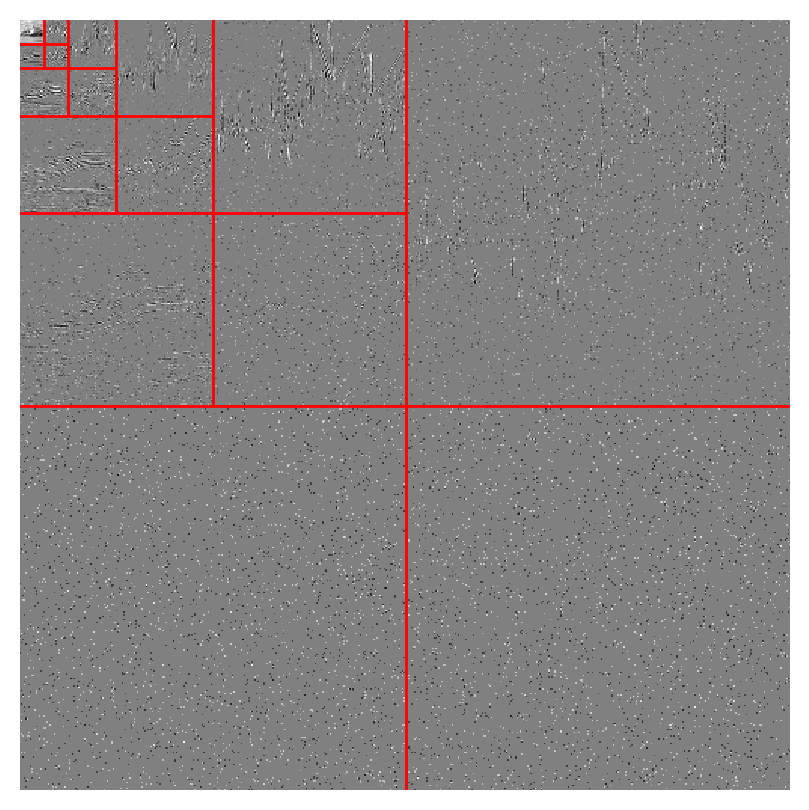

In [36]:
# Back to an array for graphical representation
coeffs_hard_arr, slices = pywt.coeffs_to_array(coeffs_hard)

plt.figure(figsize=(5, 5), dpi=200)
plot_wavelet(coeffs_hard_arr, Jmin=Jmax - J);

#### Reconstruction

In [37]:
I_den = pywt.waverecn(
    coeffs_hard, "sym8", mode="periodization"
)  # Multilevel n-dimensional Inverse Discrete Wavelet Transform

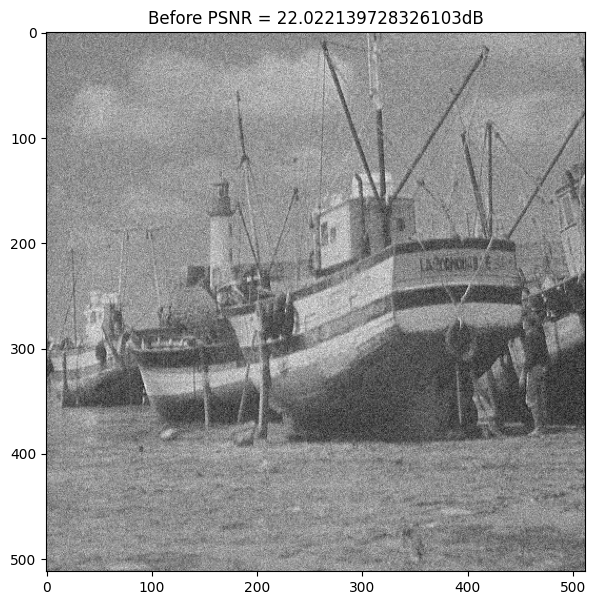

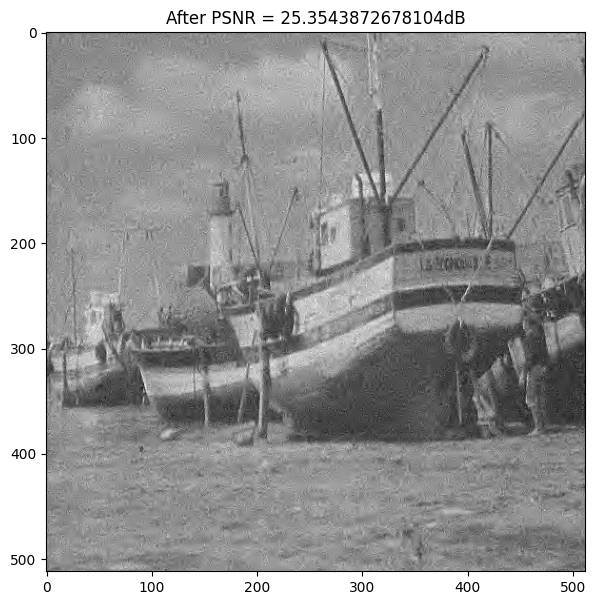

In [38]:
psnr2 = psnr(I, I_den, vmax=-1)
fig = plt.figure(figsize=(15, 7))
plt.imshow(I_noisy, cmap="gray")
title("Before PSNR = {}dB".format(psnr1))
# plt.colorbar()
fig = plt.figure(figsize=(15, 7))
plt.imshow(I_den, cmap="gray")
title("After PSNR = {}dB".format(psnr2))
# plt.colorbar()
plt.show()

### Exercise 4

1. Observe the effect of the level of the decomposition and of the threshold.
2. Optimize the parameters of your wavelet denoising strategy to get the best possible PSNR.

### Answers to Exercise 4

**Question 1.** PSNR of the denoised image as a function of the threshold (in units of $\sigma$) for different decomposition levels $J$ (`sym8`, hard thresholding of the details only).

PSNR of the noisy image: 22.02 dB


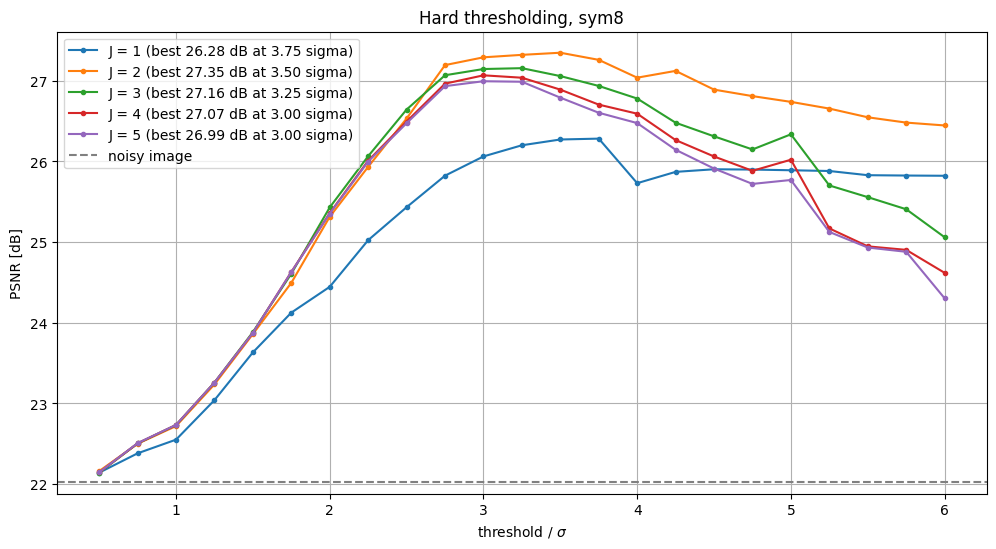

In [39]:
def denoise_dwt(img_noisy, wavelet, J, thres, mode="hard"):
    # wavelet denoising: thresholding of the detail coefficients, approximation preserved
    coeffs_d = pywt.wavedec2(img_noisy, wavelet=wavelet, level=J, mode="periodization")
    coeffs_d = [coeffs_d[0]] + [tuple(pywt.threshold(d, thres, mode=mode) for d in level) for level in coeffs_d[1:]]
    return pywt.waverec2(coeffs_d, wavelet, mode="periodization")


print("PSNR of the noisy image: %.2f dB" % psnr1)
k_values = np.arange(0.5, 6.01, 0.25)
figure(figsize=(12, 6))
for J in [1, 2, 3, 4, 5]:
    values = [psnr(I, denoise_dwt(I_noisy, "sym8", J, k * sigma), vmax=-1) for k in k_values]
    plot(k_values, values, ".-", label="J = %d (best %.2f dB at %.2f sigma)" % (J, max(values), k_values[np.argmax(values)]))
plt.axhline(psnr1, color="gray", linestyle="--", label="noisy image")
xlabel(r"threshold / $\sigma$")
ylabel("PSNR [dB]")
title("Hard thresholding, sym8")
legend()
grid()
show()

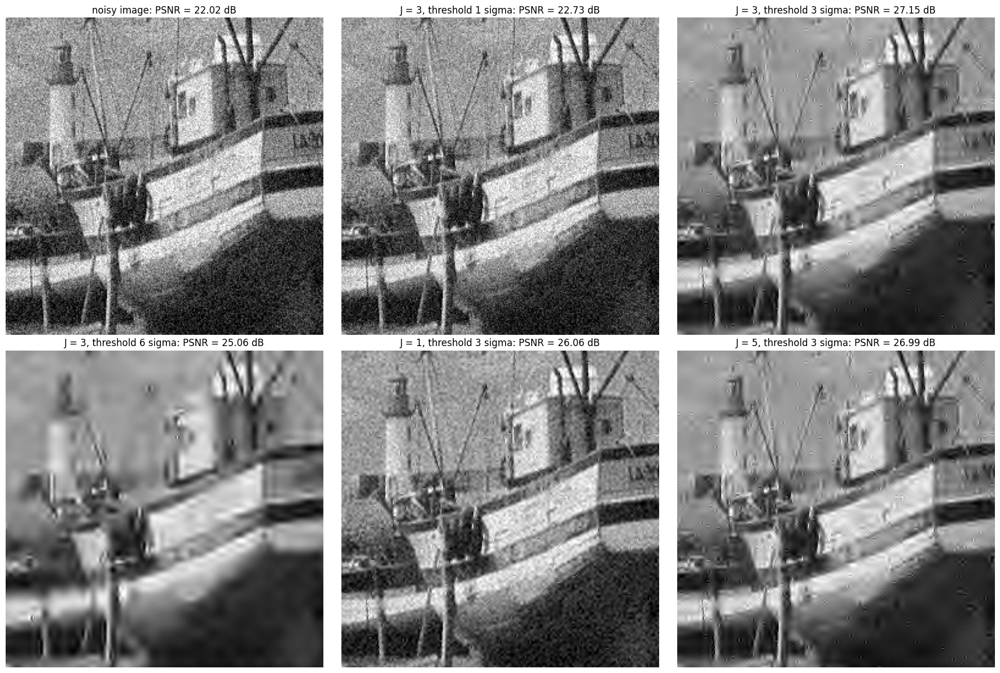

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
zoom = (slice(120, 380), slice(120, 380))
cases = [("noisy image", I_noisy),
         ("J = 3, threshold 1 sigma", denoise_dwt(I_noisy, "sym8", 3, 1 * sigma)),
         ("J = 3, threshold 3 sigma", denoise_dwt(I_noisy, "sym8", 3, 3 * sigma)),
         ("J = 3, threshold 6 sigma", denoise_dwt(I_noisy, "sym8", 3, 6 * sigma)),
         ("J = 1, threshold 3 sigma", denoise_dwt(I_noisy, "sym8", 1, 3 * sigma)),
         ("J = 5, threshold 3 sigma", denoise_dwt(I_noisy, "sym8", 5, 3 * sigma))]
for ax, (label, img) in zip(axes.ravel(), cases):
    ax.imshow(img[zoom], cmap="gray", vmin=0, vmax=1)
    ax.set_title("%s: PSNR = %.2f dB" % (label, psnr(I, img, vmax=-1)))
    ax.axis("off")
tight_layout()
show()

With an orthogonal wavelet and periodisation, the transform of white Gaussian noise of standard deviation $\sigma$ is again white Gaussian noise of standard deviation $\sigma$ at every level. Thresholding at $k\sigma$ therefore removes the coefficients that are compatible with pure noise and keeps the large coefficients of the edges.

**Threshold.** The PSNR increases from 22.0 dB (noisy image) when the threshold increases, reaches a maximum for a threshold of about **3 to 3.5 $\sigma$**, then decreases. With a low threshold (1 $\sigma$), about 32 % of the noise coefficients exceed the threshold and are kept and the image is still noisy (22.7 dB). With a high threshold (6 $\sigma$), many coefficients of the image itself are removed: the image becomes blurred and blocky, the ropes disappear (25.1 dB). The optimum is lower than the universal threshold $\sigma\sqrt{2 \ln N} \approx 5\sigma$ ($N = 512^2$), which is designed to remove all the noise with high probability and tends to over-smooth images.

**Number of levels.** With $J$ = 1, only the finest details are thresholded, and the approximation of level 1, which still contains noise of standard deviation $\sigma$, is kept as it is: residual noise remains everywhere and the best PSNR is only 26.3 dB. From $J$ = 2 onwards, most of the noise is removed and the curves are close: 27.35 dB for $J$ = 2, 27.16 dB for $J$ = 3, about 27.0 dB for $J$ = 4 and 5. Increasing $J$ removes the residual noise in smooth regions (the sky), but thresholding coarse-scale coefficients also creates larger artefacts (blobs and oscillations around the edges), so beyond $J$ = 2 or 3 the PSNR slightly decreases.

**Question 2.** Grid search over the wavelet, the number of levels, the threshold and the thresholding rule (hard or soft).

Best configurations (PSNR of the noisy image: 22.02 dB)
  27.88 dB  wavelet = db2      J = 2  hard thresholding, threshold = 3.500 sigma
  27.86 dB  wavelet = db2      J = 3  hard thresholding, threshold = 3.125 sigma
  27.72 dB  wavelet = db2      J = 3  soft thresholding, threshold = 1.625 sigma
  27.72 dB  wavelet = db2      J = 2  soft thresholding, threshold = 1.750 sigma
  27.70 dB  wavelet = db2      J = 4  soft thresholding, threshold = 1.500 sigma
  27.68 dB  wavelet = db2      J = 4  hard thresholding, threshold = 3.125 sigma
  27.61 dB  wavelet = db2      J = 5  hard thresholding, threshold = 3.125 sigma
  27.45 dB  wavelet = db2      J = 5  soft thresholding, threshold = 1.500 sigma
Best per wavelet:
  haar     26.42 dB (J = 3, hard, 3.000 sigma)
  db2      27.88 dB (J = 2, hard, 3.500 sigma)
  db4      27.42 dB (J = 2, soft, 1.625 sigma)
  sym4     27.42 dB (J = 2, hard, 3.375 sigma)
  sym8     27.38 dB (J = 2, soft, 1.625 sigma)
  coif3    27.26 dB (J = 3, hard, 3.375 sig

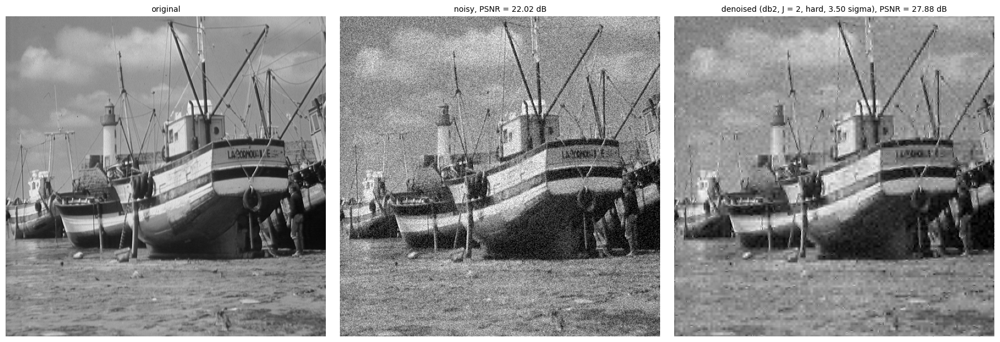

In [41]:
import itertools
import warnings

warnings.filterwarnings("ignore", message="Level value")  # boundary effect warnings for long filters

results = []
wavelets = ["haar", "db2", "db4", "sym4", "sym8", "coif3", "bior4.4"]
for wavelet, J, mode in itertools.product(wavelets, [2, 3, 4, 5], ["hard", "soft"]):
    ks = np.arange(0.5, 4.01, 0.125)
    values = [psnr(I, denoise_dwt(I_noisy, wavelet, J, k * sigma, mode), vmax=-1) for k in ks]
    i_best = int(np.argmax(values))
    results.append((values[i_best], wavelet, J, mode, ks[i_best]))

results.sort(reverse=True)
print("Best configurations (PSNR of the noisy image: %.2f dB)" % psnr1)
for value, wavelet, J, mode, k in results[:8]:
    print("  %.2f dB  wavelet = %-8s J = %d  %s thresholding, threshold = %.3f sigma" % (value, wavelet, J, mode, k))
print("Best per wavelet:")
for wavelet in wavelets:
    best = max(r for r in results if r[1] == wavelet)
    print("  %-8s %.2f dB (J = %d, %s, %.3f sigma)" % (wavelet, best[0], best[2], best[3], best[4]))

best_psnr, best_wavelet, best_J, best_mode, best_k = results[0]
I_best = denoise_dwt(I_noisy, best_wavelet, best_J, best_k * sigma, best_mode)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (label, img) in zip(axes, [("original", I), ("noisy, PSNR = %.2f dB" % psnr1, I_noisy),
                                   ("denoised (%s, J = %d, %s, %.2f sigma), PSNR = %.2f dB"
                                    % (best_wavelet, best_J, best_mode, best_k, best_psnr), I_best)]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(label, fontsize=10)
    ax.axis("off")
tight_layout()
show()

Best parameters found (PSNR of the noisy image 22.02 dB):

- **best result: 27.88 dB, `db2`, $J$ = 2, hard thresholding at 3.5 $\sigma$**, i.e. a gain of almost 6 dB;
- the other wavelets give close results, between 27.2 and 27.4 dB (`db4`, `sym4`, `sym8`, `coif3`, `bior4.4`), whereas the **Haar** wavelet is clearly worse (26.4 dB): its blocky reconstruction does not suit natural images;
- **hard thresholding** at about 3 to 3.5 $\sigma$ and **soft thresholding** at about 1.5 to 1.75 $\sigma$ give similar PSNRs (soft thresholding also shrinks the large coefficients, so it needs a lower threshold);
- $J$ = 2 or 3 is the best choice for this image and this noise level.

The short `db2` wavelet wins here because the boat image contains many thin structures (ropes, masts, letters) which are better localised by short filters, while the longer wavelets spread the thresholding artefacts over more pixels. The denoised image is much cleaner, but some noise remains in the smooth regions (sky), and the thresholding creates small blocky artefacts along the edges: these artefacts come from the lack of translation invariance of the decimated transform, which motivates Exercise 5.

> **Methodological note.** These parameters maximise the PSNR against the known clean image, so this is an **oracle selection used for evaluation**. For a real noisy image without ground truth, the wavelet, level and threshold would need to be selected from the noise model or by a data-driven criterion such as SURE or cross-validation.

### Exercise 5 (optional)

Optimize your denoising strategy by using a translation invariant wavelet transform provided by `pywt.swt2` (stationary wavelet transform).

    **Note:**

- there is currently an issue in the documentation of the `pywt.swt2` function: use the `trim_approx=True` argument to obtain the same output format as the `pywt.wavedec2` function.
- due to differences of `pywt.swt2` with respect to `pywt.wavedec2`, the `plot_wavelet` function above will not work as expected. You can directly display the array given by the `pywt.coeffs_to_array` function. Note however that the position of the vertical and horizontal details in this array are interverted compared to what is mentioned in the documentation (which can be seen by oberving the vertical and horizontal patterns, or by comparing with, e.g., the wavelet library in MATLAB).

### Answers to Exercise 5

Std of the noise in the SWT detail coefficients, levels 3 to 1: [[0.0991, 0.1004, 0.0995], [0.0992, 0.1003, 0.1001], [0.0999, 0.0996, 0.1]]


Best SWT configurations:
  29.02 dB  wavelet = haar   J = 3  hard thresholding, threshold = 2.50 sigma
  29.01 dB  wavelet = haar   J = 4  hard thresholding, threshold = 2.50 sigma
  28.88 dB  wavelet = haar   J = 2  hard thresholding, threshold = 2.50 sigma
  28.80 dB  wavelet = sym8   J = 4  hard thresholding, threshold = 2.75 sigma
  28.79 dB  wavelet = sym8   J = 3  hard thresholding, threshold = 2.75 sigma


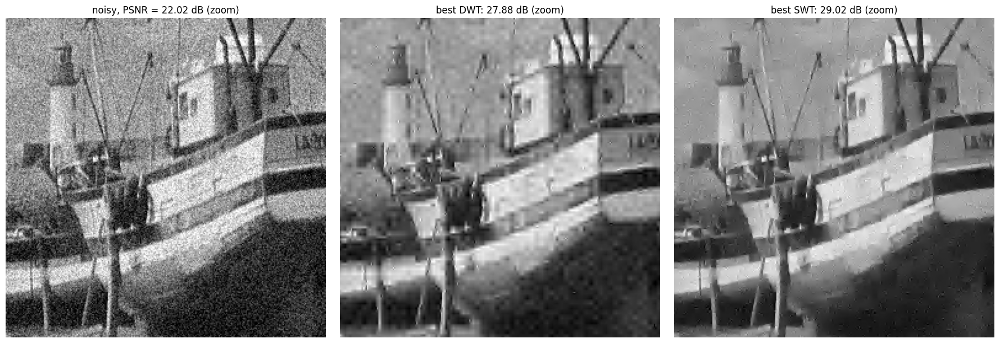

In [42]:
def denoise_swt(img_noisy, wavelet, J, thres, mode="hard"):
    # translation-invariant denoising: thresholding of the stationary wavelet transform
    coeffs_s = pywt.swt2(img_noisy, wavelet=wavelet, level=J, trim_approx=True)
    coeffs_s = [coeffs_s[0]] + [tuple(pywt.threshold(d, thres, mode=mode) for d in level) for level in coeffs_s[1:]]
    return pywt.iswt2(coeffs_s, wavelet)


# with the default normalisation (norm=False), the noise has the same standard deviation sigma at every level
noise_coeffs = pywt.swt2(noise, wavelet="sym8", level=3, trim_approx=True)
print("Std of the noise in the SWT detail coefficients, levels 3 to 1:",
      [np.round([d.std() for d in level], 4).tolist() for level in noise_coeffs[1:]])

results_swt = []
for wavelet, J, mode in itertools.product(["haar", "db4", "sym8", "coif3"], [2, 3, 4], ["hard", "soft"]):
    ks = np.arange(0.5, 4.01, 0.25)
    values = [psnr(I, denoise_swt(I_noisy, wavelet, J, k * sigma, mode), vmax=-1) for k in ks]
    i_best = int(np.argmax(values))
    results_swt.append((values[i_best], wavelet, J, mode, ks[i_best]))
results_swt.sort(reverse=True)
print("Best SWT configurations:")
for value, wavelet, J, mode, k in results_swt[:5]:
    print("  %.2f dB  wavelet = %-6s J = %d  %s thresholding, threshold = %.2f sigma" % (value, wavelet, J, mode, k))

swt_psnr, swt_wavelet, swt_J, swt_mode, swt_k = results_swt[0]
I_swt = denoise_swt(I_noisy, swt_wavelet, swt_J, swt_k * sigma, swt_mode)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
zoom = (slice(120, 380), slice(120, 380))
for ax, (label, img) in zip(axes, [("noisy, PSNR = %.2f dB" % psnr1, I_noisy),
                                   ("best DWT: %.2f dB" % best_psnr, I_best),
                                   ("best SWT: %.2f dB" % swt_psnr, I_swt)]):
    ax.imshow(img[zoom], cmap="gray", vmin=0, vmax=1)
    ax.set_title(label + " (zoom)")
    ax.axis("off")
tight_layout()
show()

The stationary wavelet transform (SWT) is the same filter bank as the DWT **without downsampling**: each level has the size of the image, so the representation is redundant ($3J + 1$ images) and **translation invariant**. With the default normalisation of PyWavelets, the noise keeps a standard deviation $\sigma$ at every level (checked above), so the same thresholds in units of $\sigma$ can be used, and the inverse `pywt.iswt2` averages the reconstructions obtained for all the shifts of the dyadic grid (equivalent to "cycle spinning").

Results:

- **best SWT result: 29.02 dB (`haar`, $J$ = 3, hard thresholding at 2.5 $\sigma$)**, against 27.88 dB for the best DWT, i.e. **+1.1 dB**, and 7 dB above the noisy image;
- `sym8` gives 28.8 dB, also better than any DWT configuration;
- the optimal threshold is slightly lower than with the DWT (2.5 to 2.75 $\sigma$).

Visually, the blocky artefacts of the DWT disappear: since the thresholding errors made for the different shifts are averaged, the reconstruction is smoother along edges, the sky is cleaner and the ropes and masts are better preserved. Interestingly, the **Haar** wavelet, the worst choice with the DWT because of its blocking artefacts, becomes the best one with the SWT: averaging over all shifts removes the blocks while keeping the excellent localisation of this very short wavelet. The price of the SWT is a computation and memory cost $3J + 1$ times higher.

As above, the quoted best SWT configuration is selected with access to the clean reference and is therefore an oracle benchmark, not a directly deployable parameter-selection rule.